In [434]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf


from pandas.plotting import scatter_matrix
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, balanced_accuracy_score, classification_report
from tensorflow.keras import models # type: ignore
from tensorflow.keras import layers # type: ignore
from tensorflow.keras import optimizers # type: ignore
from tensorflow.keras import callbacks # type: ignore
from tensorflow.keras.models import load_model # type: ignore
from sklearn.preprocessing import Normalizer
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_classif
from tensorflow.keras import regularizers #type: ignore

print(sklearn.__version__)

1.8.0


Загрузка данных
=

In [324]:
ds_original = pd.read_csv("../data/V4_classification_lr3.csv")
ds_original.Cover_Type -= 1

Работа с исходными данными
=

Описательная статистика
-

Выведем информацию о датасете, чтобы посмотреть типы данных, отсутствующие данные и в целом на доступные столбики

In [325]:
ds_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 505354 entries, 0 to 505353
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           505354 non-null  float64
 1   Aspect                              505354 non-null  float64
 2   Slope                               505354 non-null  float64
 3   Horizontal_Distance_To_Hydrology    505354 non-null  float64
 4   Vertical_Distance_To_Hydrology      505354 non-null  float64
 5   Horizontal_Distance_To_Roadways     505354 non-null  float64
 6   Hillshade_9am                       505354 non-null  float64
 7   Hillshade_Noon                      505354 non-null  float64
 8   Hillshade_3pm                       505354 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  505354 non-null  float64
 10  Wilderness_Area_0                   505354 non-null  float64
 11  Wilderness_Area_1                   5

Теперь посмотрим на то как выглядят значения

In [326]:
ds_original.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


Тут можно видеть, что много бинарных данных(надо подумать как их визулизировать) и есть подозрение, что некоторые небинарные данные будут около уникальные и придётся их объединять их по промежуткам.

Теперь выведу статистику для числовых значений.

In [327]:
ds_original.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
count,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,...,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000
mean,2951.588077,154.787515,13.767395,266.157094,46.002424,2431.980042,212.282707,223.256304,142.579133,2010.136114,...,0.091896,0.067076,0.001397,0.002753,0.000235,0.000590,0.026752,0.020592,0.013523,1.058935
std,275.484245,112.662899,7.473798,211.088728,57.901110,1600.415377,26.629387,19.580770,37.781550,1357.817931,...,0.288879,0.250153,0.037351,0.052392,0.015344,0.024276,0.161357,0.142012,0.115500,1.389396
min,1859.000000,0.000000,0.000000,0.000000,-159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2814.000000,57.000000,8.000000,108.000000,7.000000,1140.000000,199.000000,213.000000,120.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2987.000000,124.000000,13.000000,216.000000,29.000000,2078.000000,218.000000,226.000000,143.000000,1725.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,3142.000000,263.000000,18.000000,379.000000,67.000000,3475.000000,231.000000,237.000000,168.000000,2592.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000


Опытным путём было замечено, что все значения в столбиках целочисленные, значит можно заменить тип каждой колонки на int, чтобы увеличить скорость работы и увеличить читаемость

In [328]:
for column in ds_original.columns:
    ds_original[column] = ds_original[column].astype("int64")

In [329]:
ds_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 505354 entries, 0 to 505353
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           505354 non-null  int64
 1   Aspect                              505354 non-null  int64
 2   Slope                               505354 non-null  int64
 3   Horizontal_Distance_To_Hydrology    505354 non-null  int64
 4   Vertical_Distance_To_Hydrology      505354 non-null  int64
 5   Horizontal_Distance_To_Roadways     505354 non-null  int64
 6   Hillshade_9am                       505354 non-null  int64
 7   Hillshade_Noon                      505354 non-null  int64
 8   Hillshade_3pm                       505354 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  505354 non-null  int64
 10  Wilderness_Area_0                   505354 non-null  int64
 11  Wilderness_Area_1                   505354 non-null  int64
 12 

Теперь видим, что все колонки стали int. На этом заканчивается описательная статистика датасета.

Одномерная визуализация данных
-

Начнём с построения гистограмм для каждого столбика, начну с стобика Elevation

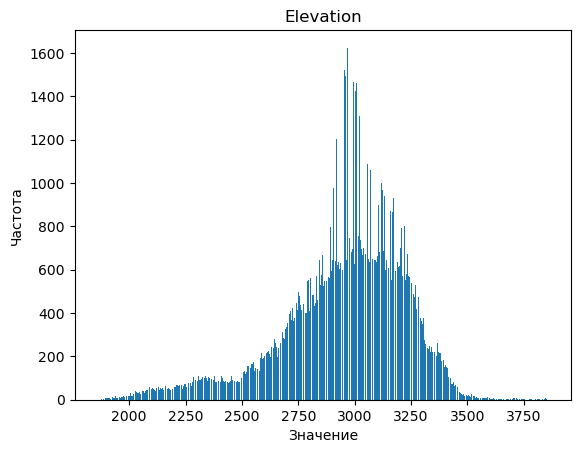

In [330]:
elevation_origin = ds_original["Elevation"].value_counts()
plt.bar(elevation_origin.index, elevation_origin.values )
plt.title('Elevation')
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

На графике видет дисбаланс количества значений. Максимальное количество сдвинуто вправо , однако слева имеется хвост с бОльшим количеством значений чем справа.

Продолжу визуализацию с Aspect

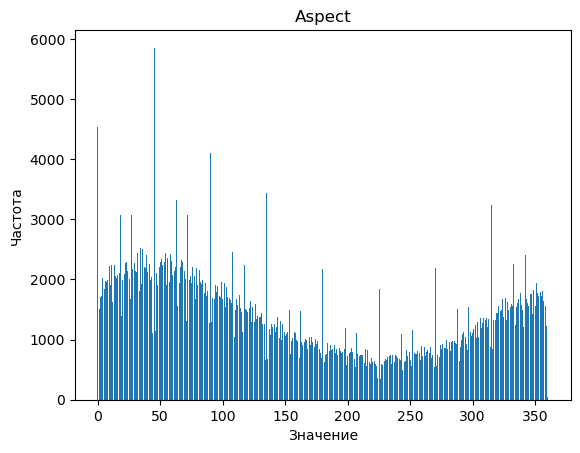

In [331]:
count = ds_original.Aspect.value_counts()
plt.bar(count.index, count.values)
plt.title("Aspect")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут видна интересная картина, распределение прям сильно не нормальное и больше похоже на равномерное. Также можно заметить некоторые резкие скачки частоты значений примерно каждые 40 единиц. Это можно связать с особенностью  параметра, однако я не очень понимаю , что он означает и как работает.

Продолжу визуализацию с Slope

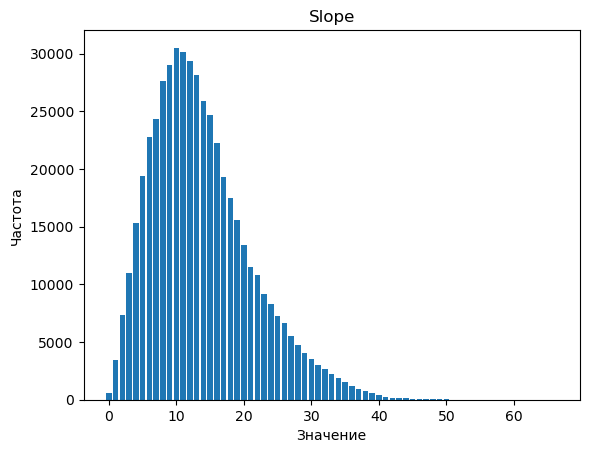

In [332]:
count = ds_original.Slope.value_counts()
plt.bar(count.index, count.values)
plt.title("Slope")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

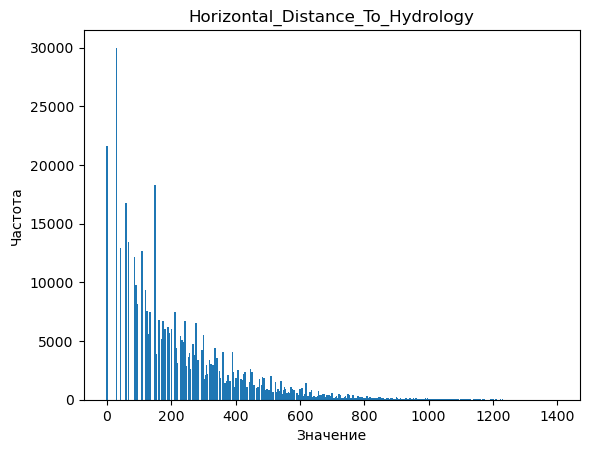

In [333]:
count = ds_original.Horizontal_Distance_To_Hydrology.value_counts()
plt.bar(count.index, count.values, width=5)
plt.title("Horizontal_Distance_To_Hydrology")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()


Тут мы можем видеть, что большая часть значний сконцентрирована в начале полосы значений. Также имеется очень тяжёлый хвост справа: значения там есть, но их количество минимальное. 

Продолжу визуализацию для Vertical_Distance_To_Hydrology

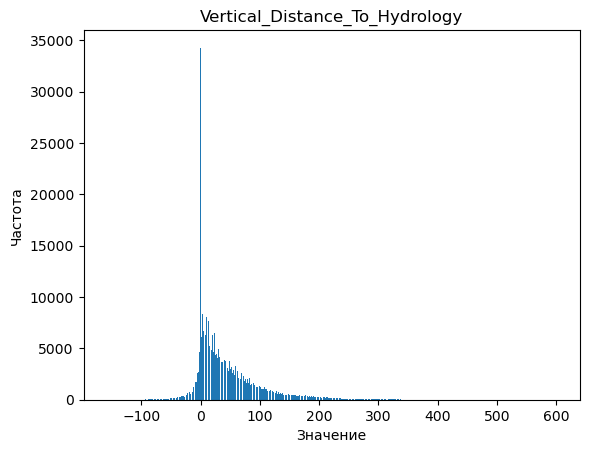

In [334]:
count = ds_original.Vertical_Distance_To_Hydrology.value_counts()
plt.bar(count.index, count.values)
plt.title("Vertical_Distance_To_Hydrology")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут видно, что большее число значений сконцентрировано около 0, что может говорить о том, что большинство лесов растёт на равнинах или около равнинных территориях, также мы можем видеть, что высота может быть как отрицательной, так и положительной (это говорит о разном расположении источников воды относительно поверхности)

Продолжу визуализацию для Horizontal_Distance_To_Roadways

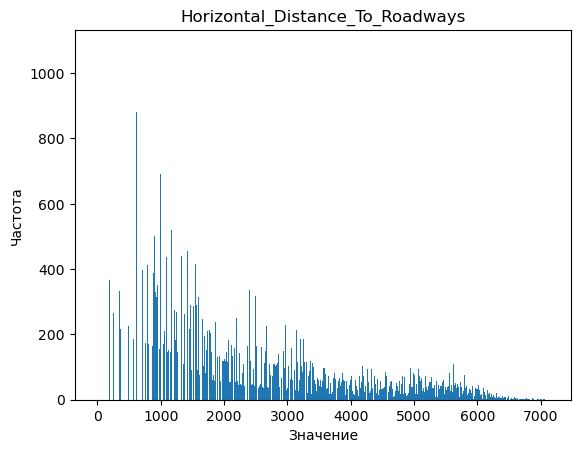

In [335]:
count = ds_original.Horizontal_Distance_To_Roadways.value_counts()
plt.bar(count.index, count.values, width=1)
plt.title("Horizontal_Distance_To_Roadways")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут мы также видим, что есть большой хвост справа , а основная масса значений сконцентрирована слева.

Продолжу виззуализацию для трёх видов Hillshade. Как я понял - это способ изображения рельефа с точки ззрения освещённости, так что значения этих полей стоит оценивать как степень освещённости участка в момент времени (чем больше число, тем больше освещённость)

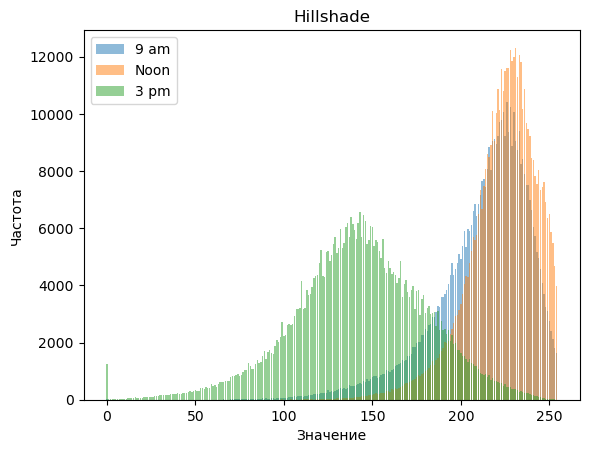

In [336]:
count = ds_original.Hillshade_9am.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_Noon.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_3pm.value_counts()
plt.bar(count.index, count.values,alpha = 0.5 )

plt.legend(["9 am", "Noon", "3 pm"])
plt.title("Hillshade")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут у нас виден явный выброс в значении 0 или около него. Предлагаю просто удалить данные, которые нахоядтся в этом значении. Вероятно, этот выброс получился из-за того, что были значения левее этого около 0-вого значения и их всех объединили в одно, а это вина сборщиков данных. 

In [337]:
print(count[count.index < 20].sort_index())

Hillshade_3pm
0     1266
1       14
2       15
3       15
4       18
5       18
6       24
7       28
8       20
9       31
10      38
11      23
12      49
13      58
14      44
15      61
16      78
17      66
18      67
19      71
Name: count, dtype: int64


In [338]:
ds_original.drop(index = ds_original[ds_original.Hillshade_3pm ==0].index, inplace=True)

Теперь проверим удалились ли данные корректно, построив гистограмму заново

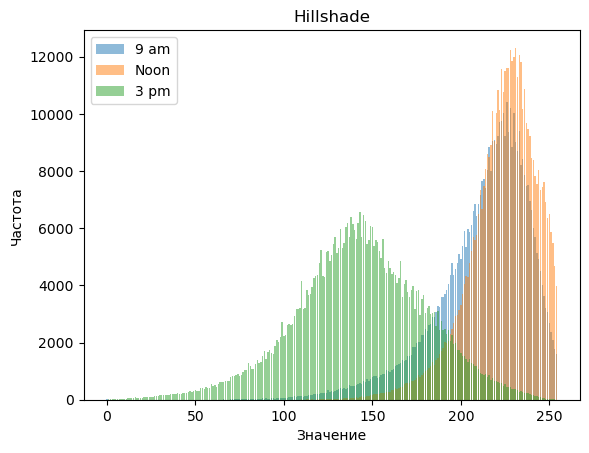

In [339]:
count = ds_original.Hillshade_9am.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_Noon.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_3pm.value_counts()
plt.bar(count.index, count.values,alpha = 0.5 )

plt.legend(["9 am", "Noon", "3 pm"])
plt.title("Hillshade")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

In [340]:
ds_original.info()

<class 'pandas.DataFrame'>
Index: 504088 entries, 0 to 505353
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           504088 non-null  int64
 1   Aspect                              504088 non-null  int64
 2   Slope                               504088 non-null  int64
 3   Horizontal_Distance_To_Hydrology    504088 non-null  int64
 4   Vertical_Distance_To_Hydrology      504088 non-null  int64
 5   Horizontal_Distance_To_Roadways     504088 non-null  int64
 6   Hillshade_9am                       504088 non-null  int64
 7   Hillshade_Noon                      504088 non-null  int64
 8   Hillshade_3pm                       504088 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  504088 non-null  int64
 10  Wilderness_Area_0                   504088 non-null  int64
 11  Wilderness_Area_1                   504088 non-null  int64
 12  Wild

Теперь всё хорошо, хоть и количество данных уменьшилось(незначительно).

Поговорим в общем про все Hillshade. Они ведут себя в принципе логично: максимальные показания освещённости находяться в Noon, тогда как минимум в 3 pm.

Продолжу визуализацию с Horizontal_Distance_To_Fire_Points

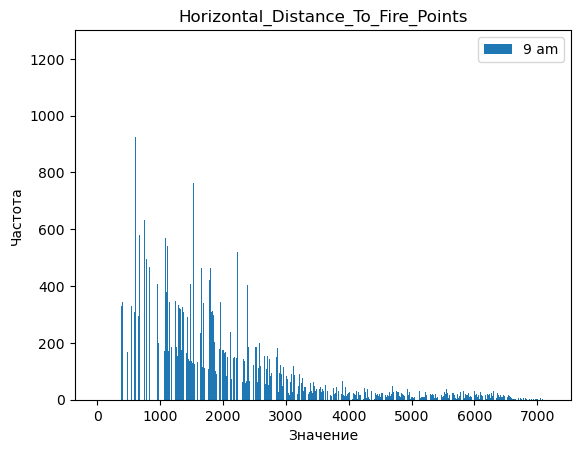

In [341]:
count = ds_original.Horizontal_Distance_To_Fire_Points.value_counts()
plt.bar(count.index, count.values )

plt.legend(["9 am", "Noon", "3 pm"])
plt.title("Horizontal_Distance_To_Fire_Points")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Теперь я мне предстоит визуализировать Wilderness_Area_x, которые переводятся как "дикость местности", и имеет бинарный формат. Я предлагаю по отдельности не визуализировать их (так как признаков 4, то я понятия не имею как они работают и что означают), а отобразить на гистограмме сразу все 1 колонки.

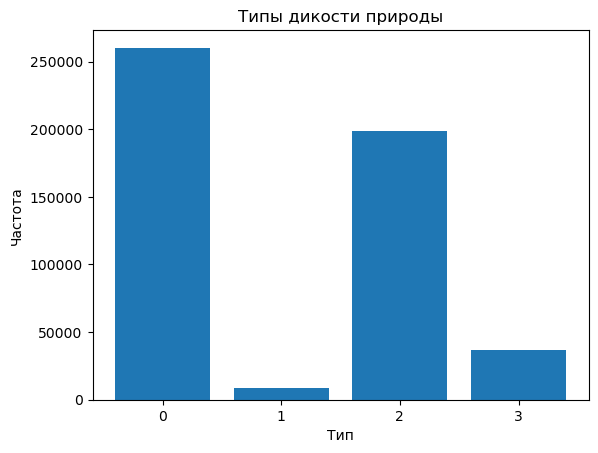

In [342]:
wilderness_area_x_count = np.zeros(4, dtype=np.int64)
for i in range(0,4):
    wilderness_area_x_count[i] = ds_original[f"Wilderness_Area_{i}"].sum()

plt.bar([0,1,2,3],wilderness_area_x_count)
plt.title("Типы дикости природы")
plt.xlabel("Тип")
plt.ylabel("Частота")
plt.xticks([0,1,2,3])
plt.show()

Тут можно увидеть, что почему-то первый и 4 тип дикости больше всего распространены, не знаю как это интерпретировать, но оно так есть. Продолжу визуализацию с Soil_Type_x и буду действовать точно также

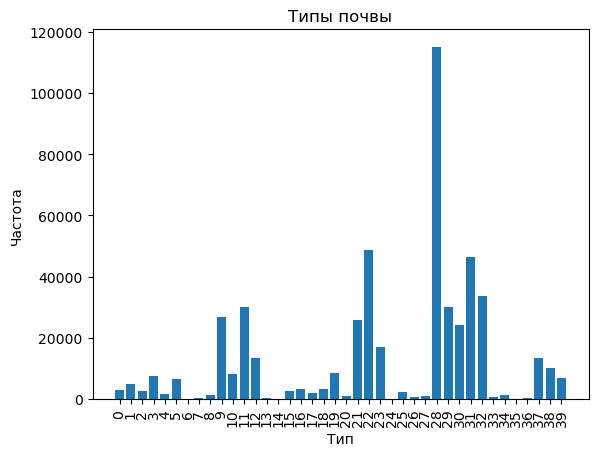

In [343]:
soil_type_x_count = np.zeros(40)
soil_types = np.arange(0,40)
for i in range(0, 40):
    soil_type_x_count[i] = ds_original[f"Soil_Type_{i}"].sum()

plt.bar(soil_types, soil_type_x_count)
plt.title("Типы почвы")
plt.xlabel("Тип")
plt.ylabel("Частота")
plt.xticks(soil_types, rotation = 90)
plt.show()

Мы можем видеть что этот параметр распределён неравномернно

Завершу одномерную визуализацию с последни столбиком Cover_Type

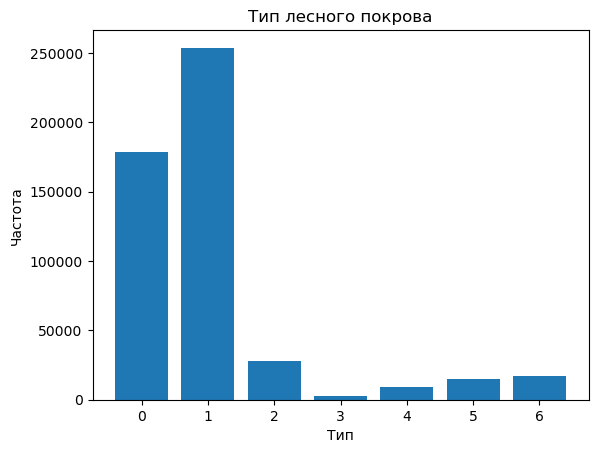

In [344]:
cover_type_counts = ds_original.Cover_Type.value_counts()
cover_type_counts.sort_index(inplace=True)

plt.bar(cover_type_counts.index, cover_type_counts.values)
plt.title("Тип лесного покрова")
plt.ylabel("Частота")
plt.xlabel("Тип")
plt.show()

Мне кажется мы видим весьма логичную картину - определённых типов лесного покрова всегда больше чем остальных, так что противоречия я не вижу.

Двумерная визуализация
-

Построю тепловую карту корреляции для признаков. Cчитать корреляцию по Soil_Type и Wildness_Type бесполезно, так как это бывшие категориальные признаки( как мне кажется ), так что их сключу

<Axes: >

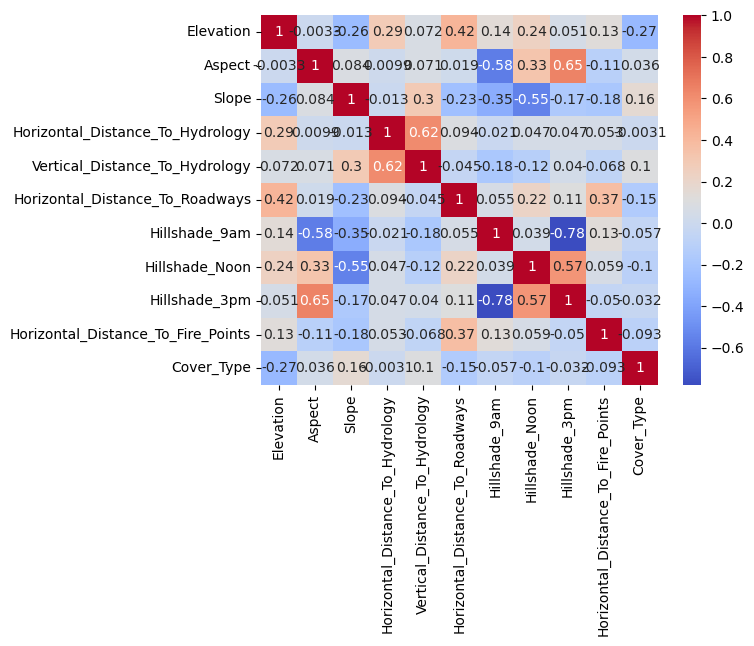

In [345]:
true_numeric_cols = ["Elevation","Aspect","Slope","Horizontal_Distance_To_Hydrology","Vertical_Distance_To_Hydrology","Horizontal_Distance_To_Roadways", "Hillshade_9am","Hillshade_Noon","Hillshade_3pm","Horizontal_Distance_To_Fire_Points", "Cover_Type" ]
corr_matrix = ds_original[true_numeric_cols].corr()
sns.heatmap(corr_matrix,annot=True,  cmap = 'coolwarm')

Тут мы видим почти полное отсутсвие корреляции с Cover_Type, только признаки Elavetion, Slope, Horizontal_Distance_To_Roadways, матрицу рассения построю только для них, так как с посмтройкой для всех мой ноутбук не справляется 

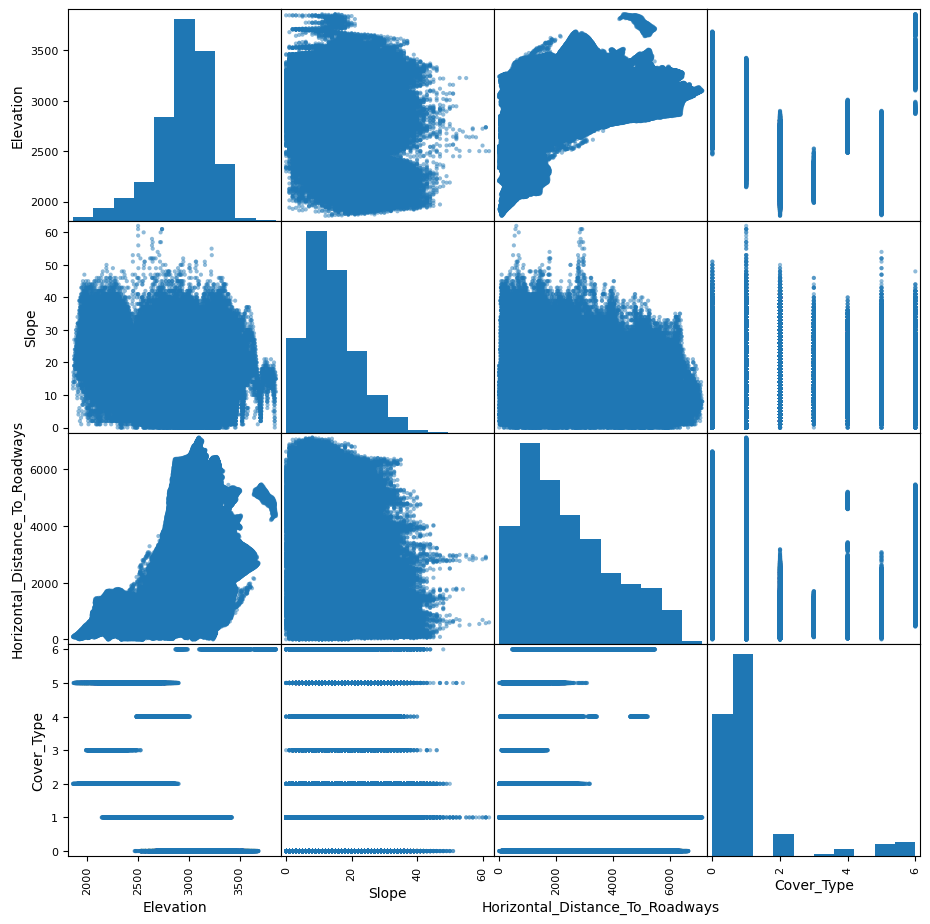

In [346]:
true_numeric_cols = ["Elevation", "Slope", "Horizontal_Distance_To_Roadways","Cover_Type"]
scatter_matrix(ds_original[true_numeric_cols], figsize=(11,11))
plt.show()

Тут корреляцию разглядеть сложно, так как значениц cover_type не много, можно построить следующий график и посмотреть

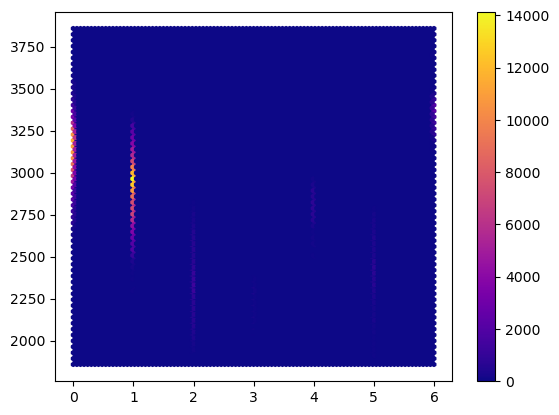

In [347]:
plt.hexbin(ds_original.Cover_Type, ds_original.Elevation, cmap='plasma' )
plt.colorbar()

Тут видно, что есть небольшая нелинейная зависимость, однако большинство значений сконцентрировано в значении 2. Выведу аналогичные графики для оставшихся признаков

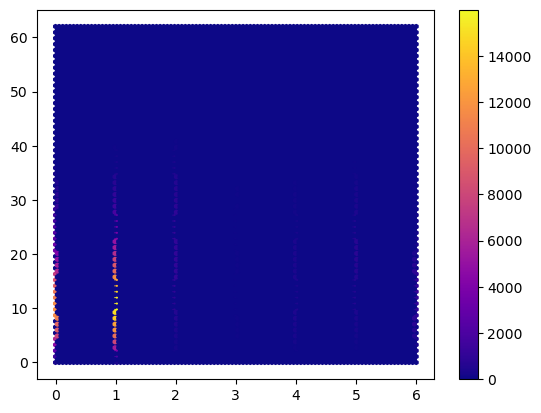

In [348]:
plt.hexbin(ds_original.Cover_Type, ds_original.Slope, cmap='plasma' )
plt.colorbar()

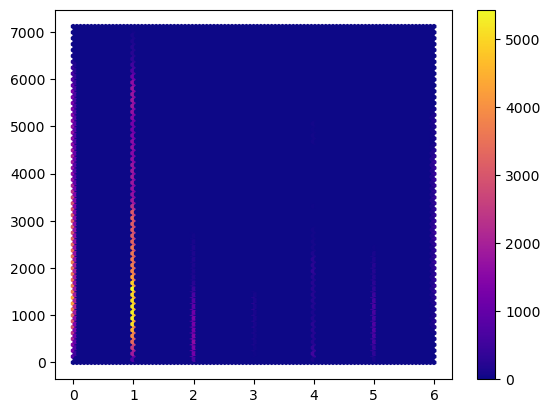

In [349]:
plt.hexbin(ds_original.Cover_Type, ds_original.Horizontal_Distance_To_Roadways, cmap='plasma' )
plt.colorbar()

Мне пока слодно что-то сказать, хочу попробовать сделать корреляционный анализ по Soil_type и Wildness_area. Для этого применю корреляцию Спиртмена, так как она не чувтсвительна к распределению

In [350]:
cols = ['Wilderness_Area_0', 'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3']
for col in cols:
    
    corr_coefficient, p_value = spearmanr(ds_original[col], ds_original['Cover_Type'])
    print(f"{col}: Spearman's ρ = {corr_coefficient:.3f} (p-value = {p_value:.4f})")

Wilderness_Area_0: Spearman's ρ = -0.221 (p-value = 0.0000)
Wilderness_Area_1: Spearman's ρ = -0.072 (p-value = 0.0000)
Wilderness_Area_2: Spearman's ρ = 0.028 (p-value = 0.0000)
Wilderness_Area_3: Spearman's ρ = 0.408 (p-value = 0.0000)


Тут мы можем видеть, что есть довольно сильная корреляция с Wildness_Area_3

In [351]:
wa_cols = [ f"Soil_Type_{x}" for x in range(0, 40)]
res = {}
for col in wa_cols:
    
    corr_coefficient, p_value = spearmanr(ds_original[col], ds_original['Cover_Type'])
    res[col] = corr_coefficient
    
sorted_dict = dict(sorted(res.items(), key=lambda x: x[1], reverse=True))
for val, i in sorted_dict.items():
    print(val, i)

    

Soil_Type_9 0.2823752710801973
Soil_Type_5 0.1579043650274892
Soil_Type_1 0.14758651086005228
Soil_Type_3 0.13726672315779606
Soil_Type_0 0.11706648291224359
Soil_Type_2 0.10662933944382524
Soil_Type_4 0.08796321699903721
Soil_Type_16 0.08630239151529058
Soil_Type_10 0.08044160855090607
Soil_Type_11 0.06417438564607254
Soil_Type_12 0.06362946422285663
Soil_Type_13 0.04399372634083913
Soil_Type_36 0.043878080262079414
Soil_Type_34 0.04172370041049927
Soil_Type_17 0.031123516246530685
Soil_Type_29 0.0213183087316239
Soil_Type_25 0.01872636950910259
Soil_Type_33 0.01761720516161623
Soil_Type_27 0.01501520014288768
Soil_Type_35 0.014911889029615906
Soil_Type_38 0.01368371633544824
Soil_Type_37 0.011338441304925244
Soil_Type_15 0.0100376713419922
Soil_Type_26 0.00904570367873208
Soil_Type_8 0.008256476564984178
Soil_Type_6 0.005802030294656717
Soil_Type_14 0.0041887951357541696
Soil_Type_24 0.0005661617663078619
Soil_Type_7 0.00018701430508206548
Soil_Type_39 -0.010108676533368686
Soil_Type

Тут мы видим, что наилучшая корреляцию достигает Soil_Type_9, Soil_Type_21, Soil_Type_22

Логистическая регрессия
-

Начну с логичтической регрессии без изменения датасета. Только начну с раделением по выборкам

In [352]:
ds_original_learn, ds_original_control = train_test_split(ds_original, test_size=0.1)
ds_original_control, ds_original_test = train_test_split(ds_original_control, test_size= 0.5)

In [353]:
Y_original_learn = ds_original_learn["Cover_Type"]
Y_original_control = ds_original_control["Cover_Type"]
Y_original_test = ds_original_test["Cover_Type"]

X_original_learn = ds_original_learn[ds_original_learn.columns.difference(['Cover_Type'])]
X_original_control = ds_original_control[ds_original_control.columns.difference(['Cover_Type'])]
X_original_test = ds_original_test[ds_original_test.columns.difference(['Cover_Type'])]


Теперь будет обучать модель, так как классов много - буду использовать гиперпараметр multi_class = "multinimial"

In [354]:
log_origin = LogisticRegression( solver = "lbfgs", max_iter=300, C=1)
log_origin.fit(X_original_learn, Y_original_learn)

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Тут мы видим, что модель не сходится даже при 300 операциях, мне кажется, что это из-за того, что данные немасшабированные, так что ничего делать сейчас не буду. Выведу метрики полученной модели

In [355]:
y_pred_origin = log_origin.predict(X_original_learn)
print("Сбалансированная точность модели log_origin на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели log_origin на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели log_origin на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1


Сбалансированная точность модели log_origin на обучающей выборке:
0.2950049901214638 

Confusion_matrix модели log_origin на обучающей выборке:
[[100533  59006     92      0      0      3    738]
 [ 40364 183532   3957      3     24    402    309]
 [    33   9055  14842      1     72   1008      5]
 [     0    114   2331      0      4      6      0]
 [   256   7948    102      0      0      1     18]
 [    72   7031   5874      1     16    394      5]
 [ 13837   1489      6      0      0      0    195]] 

F1 метрики для модели log_origin на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.28853499806673255
F1 метрики по отдельным классам: 
Cover_Type_0: 0.6374
Cover_Type_1: 0.7389
Cover_Type_2: 0.5684
Cover_Type_3: 0.0000
Cover_Type_4: 0.0000
Cover_Type_5: 0.0518
Cover_Type_6: 0.0232


Мы видим крайне печальные результаты, точность составляется всего 0.29, а f1 score по некоторым классам вообще 0. Попоробую исправить ситуацию, использовав class_weigth = balanced и усилю С регуляризацию

In [356]:
log_origin = LogisticRegression( solver = "lbfgs", max_iter=500, C=0.1, class_weight="balanced")
log_origin.fit(X_original_learn, Y_original_learn)

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [357]:
y_pred_origin = log_origin.predict(X_original_learn)
print("Сбалансированная точность модели log_origin на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели log_origin на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели log_origin на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1


Сбалансированная точность модели log_origin на обучающей выборке:
0.5436193065782581 

Confusion_matrix модели log_origin на обучающей выборке:
[[55242 31875   198   126 18482   967 53482]
 [38872 99864  7653   562 53026  9938 18676]
 [  280   546 10296  4869  1897  7078    50]
 [    0     0   340  2002    14    99     0]
 [  196  1444   565    48  4958   848   266]
 [  593  1092  3550  1578  1216  5335    29]
 [ 2419   405    68     0   161     5 12469]] 

F1 метрики для модели log_origin на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.34244150843791415
F1 метрики по отдельным классам: 
Cover_Type_0: 0.4283
Cover_Type_1: 0.5490
Cover_Type_2: 0.4318
Cover_Type_3: 0.3440
Cover_Type_4: 0.1126
Cover_Type_5: 0.2833
Cover_Type_6: 0.2481


Чтож, мне удалось поправить ситуацию, однако не скажу, что модель хороша. Мне кажется, это лучший результат, которого я могу сейчас добиться, так что хочу проверить модель на контрольной выборке

In [358]:
y_pred_origin_control = log_origin.predict(X_original_control)
print("Сбалансированная точность модели log_origin на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели log_origin на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_origin_control), "\n")
print("F1 метрики для модели log_origin на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1


Сбалансированная точность модели log_origin на контрольной выборке:
0.5349200349662561 

Confusion_matrix модели log_origin на контрольной выборке:
[[3131 1813   17    5 1045   57 2927]
 [2138 5485  430   29 2865  557 1067]
 [  10   26  612  263  119  425    2]
 [   0    0   22   93    0    3    0]
 [   8   91   27    4  233   45   12]
 [  30   61  199   82   70  293    0]
 [ 137   30    4    0   12    0  725]] 

F1 метрики для модели log_origin на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.3381489648288139
F1 метрики по отдельным классам: 
Cover_Type_1: 0.4334
Cover_Type_2: 0.5464
Cover_Type_3: 0.4422
Cover_Type_4: 0.3131
Cover_Type_5: 0.0978
Cover_Type_6: 0.2771
Cover_Type_7: 0.2570


На удивление модель показала себя лучше, чем на обучающей выборке, перейду дальше к созданию нейронной модели

Нейронная сеть
-

In [359]:
neir_origin1 = models.Sequential()
neir_origin1.add(layers.Dense(54, activation='relu', input_shape = (54,)))
neir_origin1.add(layers.Dense(120, activation='relu'))
neir_origin1.add(layers.Dense(60, activation='relu'))
neir_origin1.add(layers.Dense(7, activation='softmax'))
neir_origin1.summary()

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 54)             │         2,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 120)            │         6,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 7)              │           427 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,257 (67.41 KB)

 Trainable params: 17,257 (67.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
neir_origin1.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_origin1.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir1 = neir_origin1.fit(X_original_learn, Y_original_learn, validation_data=(X_original_control, Y_original_control), callbacks = callbacks_list, epochs=100, batch_size=128)

Epoch 1/100
3539/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5416 - loss: 4.3481

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5992 - loss: 1.8984 - val_accuracy: 0.6528 - val_loss: 0.8872 - learning_rate: 0.0010
Epoch 2/100
3541/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6784 - loss: 0.8335

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6906 - loss: 0.7795 - val_accuracy: 0.7168 - val_loss: 0.6582 - learning_rate: 0.0010
Epoch 3/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7228 - loss: 0.6521 - val_accuracy: 0.6733 - val_loss: 0.8162 - learning_rate: 0.0010
Epoch 4/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7425 - loss: 0.5974

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7473 - loss: 0.5855 - val_accuracy: 0.7339 - val_loss: 0.6191 - learning_rate: 0.0010
Epoch 5/100
3543/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7605 - loss: 0.5532

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7640 - loss: 0.5451 - val_accuracy: 0.7746 - val_loss: 0.5214 - learning_rate: 0.0010
Epoch 6/100
3515/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7741 - loss: 0.5193

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7782 - loss: 0.5117 - val_accuracy: 0.7947 - val_loss: 0.4773 - learning_rate: 0.0010
Epoch 7/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7895 - loss: 0.4863 - val_accuracy: 0.7912 - val_loss: 0.4795 - learning_rate: 0.0010
Epoch 8/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7989 - loss: 0.4674 - val_accuracy: 0.7938 - val_loss: 0.4664 - learning_rate: 0.0010
Epoch 9/100
3530/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8044 - loss: 0.4553

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8061 - loss: 0.4519 - val_accuracy: 0.8171 - val_loss: 0.4331 - learning_rate: 0.0010
Epoch 10/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8128 - loss: 0.4378 - val_accuracy: 0.7927 - val_loss: 0.4874 - learning_rate: 0.0010
Epoch 11/100
3519/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8173 - loss: 0.4287

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8178 - loss: 0.4271 - val_accuracy: 0.8226 - val_loss: 0.4202 - learning_rate: 0.0010
Epoch 12/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8219 - loss: 0.4187 - val_accuracy: 0.8102 - val_loss: 0.4376 - learning_rate: 0.0010
Epoch 13/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8257 - loss: 0.4113 - val_accuracy: 0.8174 - val_loss: 0.4271 - learning_rate: 0.0010
Epoch 14/100
3510/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8281 - loss: 0.4033

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8294 - loss: 0.4022 - val_accuracy: 0.8276 - val_loss: 0.4023 - learning_rate: 0.0010
Epoch 15/100
3535/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8322 - loss: 0.3966

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8319 - loss: 0.3976 - val_accuracy: 0.8328 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 16/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8329 - loss: 0.3931

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8348 - loss: 0.3906 - val_accuracy: 0.8339 - val_loss: 0.3923 - learning_rate: 0.0010
Epoch 17/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8354 - loss: 0.3890

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8366 - loss: 0.3862 - val_accuracy: 0.8398 - val_loss: 0.3783 - learning_rate: 0.0010
Epoch 18/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8387 - loss: 0.3825 - val_accuracy: 0.8330 - val_loss: 0.3878 - learning_rate: 0.0010
Epoch 19/100
3514/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8411 - loss: 0.3771

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8416 - loss: 0.3764 - val_accuracy: 0.8484 - val_loss: 0.3588 - learning_rate: 0.0010
Epoch 20/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8429 - loss: 0.3744 - val_accuracy: 0.8380 - val_loss: 0.3862 - learning_rate: 0.0010
Epoch 21/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8453 - loss: 0.3685 - val_accuracy: 0.8357 - val_loss: 0.3854 - learning_rate: 0.0010
Epoch 22/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8462 - loss: 0.3663 - val_accuracy: 0.8479 - val_loss: 0.3646 - learning_rate: 0.0010
Epoch 23/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8478 - loss: 0.3638 - val_accuracy: 0.8457 - val_loss: 0.3637 - learning_rate: 0.0010
Epoch 24/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8502 - loss: 0.3597 - val_accuracy: 0.8418 - val_loss: 0.3783 - learning_rate: 0.0010
Epoch 25/100
3514/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8511 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8501 - loss: 0.3587 - val_accuracy: 0.8493 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 26/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8514 - loss: 0.3568 - val_accuracy: 0.8432 - val_loss: 0.3694 - learning_rate: 0.0010
Epoch 27/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8525 - loss: 0.3545 - val_accuracy: 0.8457 - val_loss: 0.3738 - learning_rate: 0.0010
Epoch 28/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8534 - loss: 0.3520 - val_accuracy: 0.8379 - val_loss: 0.3900 - learning_rate: 0.0010
Epoch 29/100
3540/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8558 - loss: 0.3457

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8544 - loss: 0.3485 - val_accuracy: 0.8555 - val_loss: 0.3481 - learning_rate: 0.0010
Epoch 30/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8557 - loss: 0.3468 - val_accuracy: 0.8403 - val_loss: 0.3797 - learning_rate: 0.0010
Epoch 31/100
3544/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8550 - loss: 0.3489

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8559 - loss: 0.3464 - val_accuracy: 0.8570 - val_loss: 0.3411 - learning_rate: 0.0010
Epoch 32/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8569 - loss: 0.3441 - val_accuracy: 0.8511 - val_loss: 0.3489 - learning_rate: 0.0010
Epoch 33/100
3508/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8580 - loss: 0.3400

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8583 - loss: 0.3402 - val_accuracy: 0.8578 - val_loss: 0.3415 - learning_rate: 0.0010
Epoch 34/100
3530/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8561 - loss: 0.3458

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8570 - loss: 0.3440 - val_accuracy: 0.8648 - val_loss: 0.3300 - learning_rate: 0.0010
Epoch 35/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8596 - loss: 0.3387 - val_accuracy: 0.8595 - val_loss: 0.3431 - learning_rate: 0.0010
Epoch 36/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8587 - loss: 0.3394 - val_accuracy: 0.8523 - val_loss: 0.3523 - learning_rate: 0.0010
Epoch 37/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8604 - loss: 0.3368 - val_accuracy: 0.8570 - val_loss: 0.3412 - learning_rate: 0.0010
Epoch 38/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8612 - loss: 0.3342 - val_accuracy: 0.8446 - val_loss: 0.3726 - learning_rate: 0.0010
Epoch 39/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8607 - loss: 0.3360 - val_accuracy: 0.8380 - val_loss: 0.3871 - learning_rate: 0.0010
Epoch 40/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8628 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8639 - loss: 0.3280 - val_accuracy: 0.8655 - val_loss: 0.3223 - learning_rate: 0.0010
Epoch 45/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8623 - loss: 0.3331 - val_accuracy: 0.8632 - val_loss: 0.3212 - learning_rate: 0.0010
Epoch 46/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8625 - loss: 0.3313 - val_accuracy: 0.8635 - val_loss: 0.3270 - learning_rate: 0.0010
Epoch 47/100
3544/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8620 - loss: 0.3339

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8631 - loss: 0.3300 - val_accuracy: 0.8660 - val_loss: 0.3228 - learning_rate: 0.0010
Epoch 48/100
3516/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8658 - loss: 0.3256

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8637 - loss: 0.3298 - val_accuracy: 0.8689 - val_loss: 0.3188 - learning_rate: 0.0010
Epoch 49/100
3543/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8640 - loss: 0.3263

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8637 - loss: 0.3274 - val_accuracy: 0.8724 - val_loss: 0.3130 - learning_rate: 0.0010
Epoch 50/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8654 - loss: 0.3242 - val_accuracy: 0.8614 - val_loss: 0.3390 - learning_rate: 0.0010
Epoch 51/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8652 - loss: 0.3247 - val_accuracy: 0.8593 - val_loss: 0.3369 - learning_rate: 0.0010
Epoch 52/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8662 - loss: 0.3241 - val_accuracy: 0.8554 - val_loss: 0.3560 - learning_rate: 0.0010
Epoch 53/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8643 - loss: 0.3273 - val_accuracy: 0.8546 - val_loss: 0.3528 - learning_rate: 0.0010
Epoch 54/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8651 - loss: 0.3257 - val_accuracy: 0.8691 - val_loss: 0.3170 - learning_rate: 0.0010
Epoch 55/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8670 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8700 - loss: 0.3146 - val_accuracy: 0.8752 - val_loss: 0.3093 - learning_rate: 0.0010
Epoch 66/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8707 - loss: 0.3157 - val_accuracy: 0.8679 - val_loss: 0.3139 - learning_rate: 0.0010
Epoch 67/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8705 - loss: 0.3147 - val_accuracy: 0.8514 - val_loss: 0.3615 - learning_rate: 0.0010
Epoch 68/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8694 - loss: 0.3175 - val_accuracy: 0.8634 - val_loss: 0.3237 - learning_rate: 0.0010
Epoch 69/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8708 - loss: 0.3136 - val_accuracy: 0.8643 - val_loss: 0.3326 - learning_rate: 0.0010
Epoch 70/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8714 - loss: 0.3133 - val_accuracy: 0.8647 - val_loss: 0.3314 - learning_rate: 0.0010
Epoch 71/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8702 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8723 - loss: 0.3100 - val_accuracy: 0.8768 - val_loss: 0.3042 - learning_rate: 0.0010
Epoch 77/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8717 - loss: 0.3122 - val_accuracy: 0.8708 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 78/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8734 - loss: 0.3075 - val_accuracy: 0.8757 - val_loss: 0.3040 - learning_rate: 0.0010
Epoch 79/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8708 - loss: 0.3142 - val_accuracy: 0.8547 - val_loss: 0.3646 - learning_rate: 0.0010
Epoch 80/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8742 - loss: 0.3054 - val_accuracy: 0.8709 - val_loss: 0.3283 - learning_rate: 0.0010
Epoch 81/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8739 - loss: 0.3076 - val_accuracy: 0.8632 - val_loss: 0.3259 - learning_rate: 0.0010
Epoch 82/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8662 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8759 - loss: 0.3035 - val_accuracy: 0.8785 - val_loss: 0.3006 - learning_rate: 0.0010
Epoch 90/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8725 - loss: 0.3107 - val_accuracy: 0.8750 - val_loss: 0.3069 - learning_rate: 0.0010
Epoch 91/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8686 - loss: 0.3193 - val_accuracy: 0.8743 - val_loss: 0.3062 - learning_rate: 0.0010
Epoch 92/100
3535/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8747 - loss: 0.3061

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8731 - loss: 0.3097 - val_accuracy: 0.8792 - val_loss: 0.2970 - learning_rate: 0.0010
Epoch 93/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8742 - loss: 0.3074 - val_accuracy: 0.8718 - val_loss: 0.3152 - learning_rate: 0.0010
Epoch 94/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8747 - loss: 0.3072 - val_accuracy: 0.8772 - val_loss: 0.3064 - learning_rate: 0.0010
Epoch 95/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8586 - loss: 0.3476 - val_accuracy: 0.8765 - val_loss: 0.3049 - learning_rate: 0.0010
Epoch 96/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8769 - loss: 0.3012 - val_accuracy: 0.8721 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 97/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8750 - loss: 0.3052 - val_accuracy: 0.8766 - val_loss: 0.3078 - learning_rate: 0.0010
Epoch 98/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8686 - 

Я решил изначально взять модель, очень похожую на представленную в материалах лекций, как-то пытаться усовершенствовать её я буду пытаться на лучшем наборе данных-модель, если это будет нейронная сеть. А теперь загрузим модель из файла и посмотрим на её метрики на обучающей и тестовой выборке.

In [361]:
best_nier_origin1 = load_model("Neir_origin1.h5")
y_pred_origin = best_nier_origin1.predict(X_original_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)


14178/14178 ━━━━━━━━━━━━━━━━━━━━ 8s 574us/step


In [362]:

print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.8074220514077027 

Confusion_matrix модели на обучающей выборке:
[[134591  23797      5      0    181     19   1779]
 [ 13345 213596    379      3    740    338    190]
 [    15   1169  22128    262     66   1376      0]
 [     0      4    360   1854      0    237      0]
 [   131   3271    131      0   4777     15      0]
 [    45   1321   1777     82     10  10158      0]
 [  1260    195      0      0      0      0  14072]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.8320103987312119
F1 метрики по отдельным классам: 
Cover_Type_0: 0.8690
Cover_Type_1: 0.9052
Cover_Type_2: 0.8887
Cover_Type_3: 0.7964
Cover_Type_4: 0.6776
Cover_Type_5: 0.7956
Cover_Type_6: 0.8915


Тут мы видим огромный прогресс!! У нас выявляются все классы и довольно неплохо, я бы сказал. Проверю как модель поведёт себя на контрольной выборке

In [363]:
y_pred_origin_control = best_nier_origin1.predict(X_original_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step


In [364]:
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_origin_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.7905913543822484 

Confusion_matrix модели на контрольной выборке:
[[ 7472  1405     0     0     9     2   107]
 [  773 11708    19     0    52    15     4]
 [    1    64  1299    13     2    78     0]
 [    0     1    24    80     0    13     0]
 [    6   172     6     0   233     3     0]
 [    2    73   102     5     4   549     0]
 [   77    13     0     0     0     0   818]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.8174626847686969
F1 метрики по отдельным классам: 
Cover_Type_1: 0.8625
Cover_Type_2: 0.9004
Cover_Type_3: 0.8937
Cover_Type_4: 0.7407
Cover_Type_5: 0.6472
Cover_Type_6: 0.7871
Cover_Type_7: 0.8906


Теперь я хочу посмотреть на графики качества модели

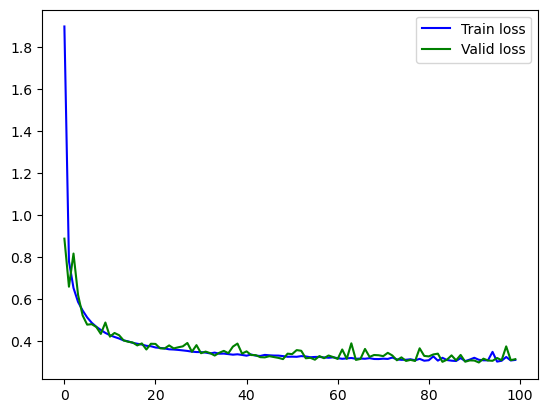

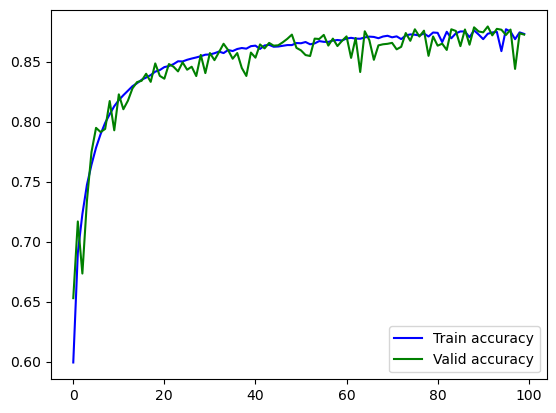

In [365]:
plt.plot(neir_origin1.history.history['loss'], color = "b", label = 'Train loss')
plt.plot(neir_origin1.history.history['val_loss'], color = "g", label = 'Valid loss')
plt.legend()
plt.show()

plt.plot(neir_origin1.history.history['accuracy'], color = "b", label = 'Train accuracy')
plt.plot(neir_origin1.history.history['val_accuracy'], color = "g", label = 'Valid accuracy')
plt.legend()
plt.show()

Сранение
-

In [366]:

log_origin_acc = 0.5696359150931365 
log_origin_f1_macro =  0.3673939401763663
log_origin_f1_classes = [0.4765, 0.5421, 0.4527, 0.3869, 0.1293, 0.2996, 0.2847]

neir_origin_acc = 0.8543783755659983 
neir_origin_f1_macro =  0.8697521765394656
neir_origin_f1_classes = [0.8904, 0.9212, 0.9096, 0.8552, 0.7422, 0.8527, 0.9170]


Тут без всяких сомнений одерживает вверх нейронная модель, её метрики на голову выше метрик обычной логистической регрессии. Далее перейдём к созданию масштабированных данных.

Работа с исходными масштабированными данными
=

Теперь мне нужнно выполнить мастабирование данных методом Нормализации. Так как масштабирование никак не влияет на распределение или корреляцию - пропущу этап с визуализациией данных

Масштабирование 
-

In [367]:
transformer = Normalizer(copy = True ).fit(X_original_learn)
X_scaled_learn = transformer.transform(X_original_learn)
X_scaled_control = transformer.transform(X_original_control)
X_scaled_test = transformer.transform(X_original_test)


Логистическая регрессия
-

Тут я буду сразу использовать class_weigth = balanced и усилю С регуляризацию, так как классы всё ещё несбалансированны по количеству, а подобные действия дали сущетсвенный прирост в прошлый раз. 

In [368]:
log_scaled = LogisticRegression( solver = "lbfgs",C = 0.1, max_iter=300, class_weight="balanced")
log_scaled.fit(X_scaled_learn, Y_original_learn)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [369]:
y_pred_scaled = log_scaled.predict(X_scaled_learn)
print("Сбалансированная точность модели на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_scaled), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_scaled), "\n")
print("F1 метрики для модели на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_scaled, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_scaled, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на обучающей выборке:
0.4325609733986146 

Confusion_matrix модели на обучающей выборке:
[[40414 20053  4781   969 22193 13255 58707]
 [33447 53553 14667  5349 34045 24079 63451]
 [   85   761 10136  6527  1279  4906  1322]
 [    1     5   287  1946   119    89     8]
 [  567   495   856   488  2673  1473  1773]
 [  142   593  3528  2430  1114  4599   987]
 [ 3073   174   166     0  1100   466 10548]] 

F1 метрики для модели на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.22675760627191588
F1 метрики по отдельным классам: 
Cover_Type_0: 0.3395
Cover_Type_1: 0.3521
Cover_Type_2: 0.3411
Cover_Type_3: 0.1930
Cover_Type_4: 0.0755
Cover_Type_5: 0.1477
Cover_Type_6: 0.1385


Как мы можем видеть - результаты неутешающие, но лучше, чем у его предшественника. Проверим модель на контрольных даннных

In [370]:
y_pred_scaled_control = log_scaled.predict(X_scaled_control)
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_scaled_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_scaled_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_scaled_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_scaled_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.4162883242445643 

Confusion_matrix модели на контрольной выборке:
[[2280 1114  262   58 1251  799 3231]
 [1885 2966  796  300 1880 1276 3468]
 [   6   50  610  344   75  305   67]
 [   0    1   17   91    3    5    1]
 [  37   34   43   30  112   74   90]
 [   5   39  218  118   57  238   60]
 [ 217    5   15    0   61   25  585]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.2224046973206065
F1 метрики по отдельным классам: 
Cover_Type_1: 0.3397
Cover_Type_2: 0.3535
Cover_Type_3: 0.3569
Cover_Type_4: 0.1719
Cover_Type_5: 0.0580
Cover_Type_6: 0.1377
Cover_Type_7: 0.1391


Тут тоже всё лучше, чем у предшественника, теперь можно переходить к нейронной сети

Нейронная сеть
-

Я буду использовать точно такую же нейронную сеть, как и в прошлый раз

In [371]:
neir_scaled = models.Sequential()
neir_scaled.add(layers.Dense(54, activation='relu', input_shape = (54,)))
neir_scaled.add(layers.Dense(120, activation='relu'))
neir_scaled.add(layers.Dense(60, activation='relu'))
neir_scaled.add(layers.Dense(7, activation='softmax'))
neir_scaled.summary()

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                │ (None, 54)             │         2,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 120)            │         6,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 7)              │           427 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,257 (67.41 KB)

 Trainable params: 17,257 (67.41 KB)

 Non-trainable params: 0 (0.00 B)

In [372]:
neir_scaled.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_scaled.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir2 = neir_scaled.fit(X_scaled_learn, Y_original_learn, validation_data=(X_scaled_control, Y_original_control), callbacks = callbacks_list, epochs=100, batch_size=128)

Epoch 1/100
3496/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5758 - loss: 1.0062

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6382 - loss: 0.8499 - val_accuracy: 0.6830 - val_loss: 0.7331 - learning_rate: 0.0010
Epoch 2/100
3535/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6896 - loss: 0.7229

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6942 - loss: 0.7133 - val_accuracy: 0.6970 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 3/100
3514/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7022 - loss: 0.6891

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7056 - loss: 0.6818 - val_accuracy: 0.7106 - val_loss: 0.6621 - learning_rate: 0.0010
Epoch 4/100
3513/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7128 - loss: 0.6644

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7150 - loss: 0.6576 - val_accuracy: 0.7242 - val_loss: 0.6370 - learning_rate: 0.0010
Epoch 5/100
3538/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7219 - loss: 0.6408

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7248 - loss: 0.6350 - val_accuracy: 0.7330 - val_loss: 0.6200 - learning_rate: 0.0010
Epoch 6/100
3518/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7309 - loss: 0.6202

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7335 - loss: 0.6138 - val_accuracy: 0.7408 - val_loss: 0.5953 - learning_rate: 0.0010
Epoch 7/100
3513/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7399 - loss: 0.5994

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7408 - loss: 0.5976 - val_accuracy: 0.7443 - val_loss: 0.5837 - learning_rate: 0.0010
Epoch 8/100
3542/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7457 - loss: 0.5874

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7455 - loss: 0.5873 - val_accuracy: 0.7533 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 9/100
3518/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7479 - loss: 0.5804

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7491 - loss: 0.5791 - val_accuracy: 0.7617 - val_loss: 0.5599 - learning_rate: 0.0010
Epoch 10/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7515 - loss: 0.5737 - val_accuracy: 0.6860 - val_loss: 0.6818 - learning_rate: 0.0010
Epoch 11/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7554 - loss: 0.5661 - val_accuracy: 0.7523 - val_loss: 0.5710 - learning_rate: 0.0010
Epoch 12/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7585 - loss: 0.5571 - val_accuracy: 0.7285 - val_loss: 0.5961 - learning_rate: 0.0010
Epoch 13/100
3540/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7608 - loss: 0.5516

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7616 - loss: 0.5500 - val_accuracy: 0.7686 - val_loss: 0.5356 - learning_rate: 0.0010
Epoch 14/100
3541/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7641 - loss: 0.5459

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7643 - loss: 0.5444 - val_accuracy: 0.7726 - val_loss: 0.5259 - learning_rate: 0.0010
Epoch 15/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7673 - loss: 0.5379 - val_accuracy: 0.7687 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 16/100
3531/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7685 - loss: 0.5329

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7696 - loss: 0.5317 - val_accuracy: 0.7748 - val_loss: 0.5186 - learning_rate: 0.0010
Epoch 17/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7723 - loss: 0.5251 - val_accuracy: 0.7661 - val_loss: 0.5389 - learning_rate: 0.0010
Epoch 18/100
3540/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7748 - loss: 0.5208

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7750 - loss: 0.5208 - val_accuracy: 0.7762 - val_loss: 0.5119 - learning_rate: 0.0010
Epoch 19/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7766 - loss: 0.5175

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7769 - loss: 0.5156 - val_accuracy: 0.7825 - val_loss: 0.5020 - learning_rate: 0.0010
Epoch 20/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7793 - loss: 0.5104 - val_accuracy: 0.7742 - val_loss: 0.5188 - learning_rate: 0.0010
Epoch 21/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7809 - loss: 0.5062 - val_accuracy: 0.7698 - val_loss: 0.5223 - learning_rate: 0.0010
Epoch 22/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7821 - loss: 0.5030 - val_accuracy: 0.7678 - val_loss: 0.5214 - learning_rate: 0.0010
Epoch 23/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7847 - loss: 0.4975 - val_accuracy: 0.7634 - val_loss: 0.5279 - learning_rate: 0.0010
Epoch 24/100
3537/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7862 - loss: 0.4941

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7864 - loss: 0.4936 - val_accuracy: 0.7851 - val_loss: 0.4913 - learning_rate: 0.0010
Epoch 25/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7885 - loss: 0.4888 - val_accuracy: 0.7796 - val_loss: 0.5051 - learning_rate: 0.0010
Epoch 26/100
3523/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7907 - loss: 0.4842

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7904 - loss: 0.4844 - val_accuracy: 0.7888 - val_loss: 0.4857 - learning_rate: 0.0010
Epoch 27/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7915 - loss: 0.4817

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7918 - loss: 0.4815 - val_accuracy: 0.7959 - val_loss: 0.4750 - learning_rate: 0.0010
Epoch 28/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7934 - loss: 0.4772 - val_accuracy: 0.7946 - val_loss: 0.4723 - learning_rate: 0.0010
Epoch 29/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7944 - loss: 0.4752 - val_accuracy: 0.7949 - val_loss: 0.4725 - learning_rate: 0.0010
Epoch 30/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7954 - loss: 0.4723 - val_accuracy: 0.7959 - val_loss: 0.4664 - learning_rate: 0.0010
Epoch 31/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7976 - loss: 0.4679 - val_accuracy: 0.7815 - val_loss: 0.4979 - learning_rate: 0.0010
Epoch 32/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7986 - loss: 0.4650 - val_accuracy: 0.7839 - val_loss: 0.5017 - learning_rate: 0.0010
Epoch 33/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8003 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8025 - loss: 0.4576 - val_accuracy: 0.8049 - val_loss: 0.4487 - learning_rate: 0.0010
Epoch 35/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8031 - loss: 0.4551 - val_accuracy: 0.7979 - val_loss: 0.4606 - learning_rate: 0.0010
Epoch 36/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8046 - loss: 0.4520 - val_accuracy: 0.7879 - val_loss: 0.4739 - learning_rate: 0.0010
Epoch 37/100
3539/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8041 - loss: 0.4516

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8057 - loss: 0.4493 - val_accuracy: 0.8073 - val_loss: 0.4422 - learning_rate: 0.0010
Epoch 38/100
3515/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8066 - loss: 0.4481

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8070 - loss: 0.4478 - val_accuracy: 0.8108 - val_loss: 0.4383 - learning_rate: 0.0010
Epoch 39/100
3502/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8078 - loss: 0.4459

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8079 - loss: 0.4453 - val_accuracy: 0.8119 - val_loss: 0.4304 - learning_rate: 0.0010
Epoch 40/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8101 - loss: 0.4414 - val_accuracy: 0.7975 - val_loss: 0.4629 - learning_rate: 0.0010
Epoch 41/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8107 - loss: 0.4382 - val_accuracy: 0.8006 - val_loss: 0.4525 - learning_rate: 0.0010
Epoch 42/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8117 - loss: 0.4366 - val_accuracy: 0.8026 - val_loss: 0.4460 - learning_rate: 0.0010
Epoch 43/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8125 - loss: 0.4354 - val_accuracy: 0.8028 - val_loss: 0.4612 - learning_rate: 0.0010
Epoch 44/100
3513/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8131 - loss: 0.4335

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8140 - loss: 0.4321 - val_accuracy: 0.8178 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 45/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8147 - loss: 0.4307 - val_accuracy: 0.8131 - val_loss: 0.4292 - learning_rate: 0.0010
Epoch 46/100
3533/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8163 - loss: 0.4271

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8160 - loss: 0.4273 - val_accuracy: 0.8206 - val_loss: 0.4171 - learning_rate: 0.0010
Epoch 47/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8170 - loss: 0.4255 - val_accuracy: 0.7962 - val_loss: 0.4613 - learning_rate: 0.0010
Epoch 48/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8187 - loss: 0.4234 - val_accuracy: 0.7824 - val_loss: 0.4995 - learning_rate: 0.0010
Epoch 49/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8192 - loss: 0.4220 - val_accuracy: 0.8132 - val_loss: 0.4345 - learning_rate: 0.0010
Epoch 50/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8199 - loss: 0.4200

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8204 - loss: 0.4193 - val_accuracy: 0.8213 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 51/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8213 - loss: 0.4168 - val_accuracy: 0.8211 - val_loss: 0.4111 - learning_rate: 0.0010
Epoch 52/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8215 - loss: 0.4164 - val_accuracy: 0.8165 - val_loss: 0.4180 - learning_rate: 0.0010
Epoch 53/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8231 - loss: 0.4137 - val_accuracy: 0.7936 - val_loss: 0.4712 - learning_rate: 0.0010
Epoch 54/100
3522/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8239 - loss: 0.4139

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8238 - loss: 0.4120 - val_accuracy: 0.8270 - val_loss: 0.4066 - learning_rate: 0.0010
Epoch 55/100
3513/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8233 - loss: 0.4123

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8238 - loss: 0.4115 - val_accuracy: 0.8304 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 56/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8255 - loss: 0.4095 - val_accuracy: 0.8236 - val_loss: 0.4052 - learning_rate: 0.0010
Epoch 57/100
3531/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8255 - loss: 0.4081

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8260 - loss: 0.4078 - val_accuracy: 0.8313 - val_loss: 0.3973 - learning_rate: 0.0010
Epoch 58/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8268 - loss: 0.4052 - val_accuracy: 0.8219 - val_loss: 0.4117 - learning_rate: 0.0010
Epoch 59/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8277 - loss: 0.4047 - val_accuracy: 0.8274 - val_loss: 0.4052 - learning_rate: 0.0010
Epoch 60/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8279 - loss: 0.4023 - val_accuracy: 0.8115 - val_loss: 0.4269 - learning_rate: 0.0010
Epoch 61/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8290 - loss: 0.4011 - val_accuracy: 0.8027 - val_loss: 0.4468 - learning_rate: 0.0010
Epoch 62/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8293 - loss: 0.3998 - val_accuracy: 0.8250 - val_loss: 0.4074 - learning_rate: 0.0010
Epoch 63/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8304 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8323 - loss: 0.3938 - val_accuracy: 0.8370 - val_loss: 0.3835 - learning_rate: 0.0010
Epoch 68/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8342 - loss: 0.3904 - val_accuracy: 0.8341 - val_loss: 0.3928 - learning_rate: 0.0010
Epoch 69/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8332 - loss: 0.3916 - val_accuracy: 0.8189 - val_loss: 0.4166 - learning_rate: 0.0010
Epoch 70/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8339 - loss: 0.3894

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8342 - loss: 0.3893 - val_accuracy: 0.8399 - val_loss: 0.3808 - learning_rate: 0.0010
Epoch 71/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8354 - loss: 0.3880 - val_accuracy: 0.8370 - val_loss: 0.3824 - learning_rate: 0.0010
Epoch 72/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8360 - loss: 0.3860 - val_accuracy: 0.8367 - val_loss: 0.3889 - learning_rate: 0.0010
Epoch 73/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8361 - loss: 0.3856 - val_accuracy: 0.8386 - val_loss: 0.3815 - learning_rate: 0.0010
Epoch 74/100
3508/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8375 - loss: 0.3847

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8372 - loss: 0.3836 - val_accuracy: 0.8417 - val_loss: 0.3753 - learning_rate: 0.0010
Epoch 75/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8371 - loss: 0.3825 - val_accuracy: 0.8298 - val_loss: 0.3995 - learning_rate: 0.0010
Epoch 76/100
3506/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8399 - loss: 0.3785

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8387 - loss: 0.3808 - val_accuracy: 0.8423 - val_loss: 0.3741 - learning_rate: 0.0010
Epoch 77/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8390 - loss: 0.3806 - val_accuracy: 0.8353 - val_loss: 0.3900 - learning_rate: 0.0010
Epoch 78/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8404 - loss: 0.3803

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8402 - loss: 0.3790 - val_accuracy: 0.8429 - val_loss: 0.3756 - learning_rate: 0.0010
Epoch 79/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8396 - loss: 0.3783 - val_accuracy: 0.8384 - val_loss: 0.3817 - learning_rate: 0.0010
Epoch 80/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8408 - loss: 0.3770 - val_accuracy: 0.8330 - val_loss: 0.3868 - learning_rate: 0.0010
Epoch 81/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8407 - loss: 0.3758 - val_accuracy: 0.8407 - val_loss: 0.3752 - learning_rate: 0.0010
Epoch 82/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8412 - loss: 0.3748 - val_accuracy: 0.8334 - val_loss: 0.3882 - learning_rate: 0.0010
Epoch 83/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8412 - loss: 0.3746 - val_accuracy: 0.8372 - val_loss: 0.3847 - learning_rate: 0.0010
Epoch 84/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8424 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8563 - loss: 0.3454 - val_accuracy: 0.8558 - val_loss: 0.3478 - learning_rate: 2.5000e-04
Epoch 88/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8565 - loss: 0.3439 - val_accuracy: 0.8539 - val_loss: 0.3514 - learning_rate: 2.5000e-04
Epoch 89/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8566 - loss: 0.3437 - val_accuracy: 0.8537 - val_loss: 0.3489 - learning_rate: 2.5000e-04
Epoch 90/100
3542/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8570 - loss: 0.3429

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8568 - loss: 0.3432 - val_accuracy: 0.8566 - val_loss: 0.3464 - learning_rate: 2.5000e-04
Epoch 91/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8573 - loss: 0.3422 - val_accuracy: 0.8547 - val_loss: 0.3486 - learning_rate: 2.5000e-04
Epoch 92/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8576 - loss: 0.3418 - val_accuracy: 0.8561 - val_loss: 0.3462 - learning_rate: 2.5000e-04
Epoch 93/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8575 - loss: 0.3414 - val_accuracy: 0.8536 - val_loss: 0.3538 - learning_rate: 2.5000e-04
Epoch 94/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8580 - loss: 0.3404 - val_accuracy: 0.8519 - val_loss: 0.3522 - learning_rate: 2.5000e-04
Epoch 95/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8581 - loss: 0.3404

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8582 - loss: 0.3401 - val_accuracy: 0.8570 - val_loss: 0.3434 - learning_rate: 2.5000e-04
Epoch 96/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8580 - loss: 0.3401 - val_accuracy: 0.8544 - val_loss: 0.3495 - learning_rate: 2.5000e-04
Epoch 97/100
3536/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8587 - loss: 0.3398

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8588 - loss: 0.3392 - val_accuracy: 0.8573 - val_loss: 0.3456 - learning_rate: 2.5000e-04
Epoch 98/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8589 - loss: 0.3390 - val_accuracy: 0.8534 - val_loss: 0.3523 - learning_rate: 2.5000e-04
Epoch 99/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8584 - loss: 0.3387 - val_accuracy: 0.8553 - val_loss: 0.3445 - learning_rate: 2.5000e-04
Epoch 100/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8592 - loss: 0.3392

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8594 - loss: 0.3382 - val_accuracy: 0.8574 - val_loss: 0.3439 - learning_rate: 2.5000e-04


In [373]:
best_nier_scaled = load_model("Neir_scaled.h5")
y_pred_origin = best_nier_scaled.predict(X_scaled_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)

14178/14178 ━━━━━━━━━━━━━━━━━━━━ 8s 578us/step


In [374]:
print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.7874937730407431 

Confusion_matrix модели на обучающей выборке:
[[128317  30890     10      0     49     50   1056]
 [ 16368 210105    747     10    383    852    126]
 [    23    800  21953    344     26   1870      0]
 [     0      0    238   2078      0    139      0]
 [   207   4582    262      0   3205     69      0]
 [    69    730   1515    112      3  10964      0]
 [  1924    163      0      0      0      0  13440]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.8086522849868755
F1 метрики по отдельным классам: 
Cover_Type_0: 0.8352
Cover_Type_1: 0.8831
Cover_Type_2: 0.8827
Cover_Type_3: 0.8314
Cover_Type_4: 0.5346
Cover_Type_5: 0.8021
Cover_Type_6: 0.8916


Тут можем видеть, что качество модели просело, это может быть связано с типом масштабирования, который мне предложен вариантом, так как у меня много категриальных признаков, которые разбиты на бинарные столбцы, а также много столбцов с большими значениями, из-за этого значения немного некорректно преоразуются. Проверю модель на контрольных значениях

In [375]:
y_pred_origin_control = best_nier_scaled.predict(X_scaled_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step


In [376]:
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_origin_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.7761723551096518 

Confusion_matrix модели на контрольной выборке:
[[ 7198  1732     1     0     3     3    58]
 [  961 11502    43     0    24    38     3]
 [    0    35  1294    16     4   108     0]
 [    0     1    15    96     0     6     0]
 [    6   248    14     0   148     4     0]
 [    4    38    94     8     1   590     0]
 [  110    16     0     0     0     0   782]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.7983768338900609
F1 метрики по отдельным классам: 
Cover_Type_1: 0.8334
Cover_Type_2: 0.8799
Cover_Type_3: 0.8869
Cover_Type_4: 0.8067
Cover_Type_5: 0.4933
Cover_Type_6: 0.7951
Cover_Type_7: 0.8932


тут результаты тоже хуже, однако во много лучше чем у логистической регрессии. Хочу также посмотреть на графики качества модели

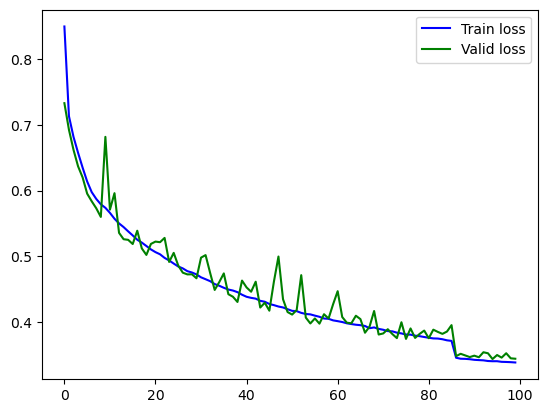

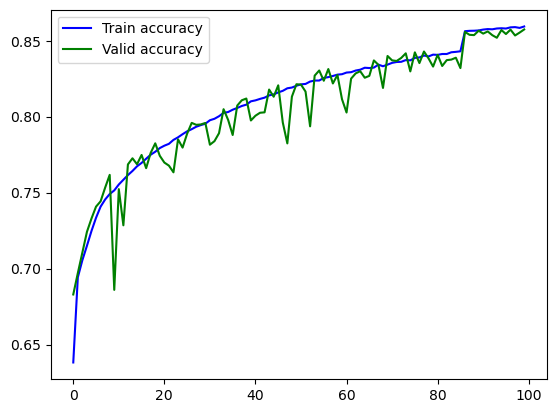

In [377]:
plt.plot(neir_scaled.history.history['loss'], color = "b", label = 'Train loss')
plt.plot(neir_scaled.history.history['val_loss'], color = "g", label = 'Valid loss')
plt.legend()
plt.show()

plt.plot(neir_scaled.history.history['accuracy'], color = "b", label = 'Train accuracy')
plt.plot(neir_scaled.history.history['val_accuracy'], color = "g", label = 'Valid accuracy')
plt.legend()
plt.show()

В отличии от предыдущего графика тут явно видно непонятные мне по природе скачки valid параметров. Перейдём к сравнению

Сравнение
-

Тут без шансов побеждает Нейронная сеть со следующими результатами: 

Сбалансированная точность модели на контрольной выборке:

0.7510203998371768 

Confusion_matrix модели на контрольной выборке:

[[ 7360  1444     2     0     3     0    32]

 [ 1315 11385    50     0    17    23     0]

 [    2    50  1236     9     0    79     0]

 [    0     0    25   123     0     7     0]

 [    7   264    12     0   177     5     0]

 [    3    40   141     1     0   556     0]

 [  227    14     0     0     0     0   595]] 


F1 метрики для модели на контрольной выборке:

F1 по всей выборке: 

Macro f1:  0.795068587476069

F1 метрики по отдельным классам: 

Cover_Type_1: 0.8291

Cover_Type_2: 0.8762

Cover_Type_3: 0.8698

Cover_Type_4: 0.8542

Cover_Type_5: 0.5347

Cover_Type_6: 0.7881

Cover_Type_7: 0.8134

Работа с исходными построенными данными
=

Так как данных у меня и так параметров у меня много, я хочу удалить числовые признаки, которые имеют слабую корреляцию. Буду проводить отбор при помощи selectkbest , f_regression и mutual_info_regression

Отбор признаков
-

In [378]:
ds_mod = ds_original.copy()


In [379]:
f_selector = SelectKBest(f_regression, k = 6)
m_selector = SelectKBest(mutual_info_classif, k = 6)

Y_mod = ds_mod["Cover_Type"]
non_goal_columns = [x for x in ds_mod.columns if x != "Cover_Type"]
X_mod = ds_mod[non_goal_columns]


fit_f = f_selector.fit(X_mod, Y_mod)
fit_m = m_selector.fit(X_mod, Y_mod)

p_values = fit_f.pvalues_
f_statics = fit_f.scores_

mi = fit_m.scores_


In [380]:
select_results = pd.DataFrame({"Parametr" : ds_mod[non_goal_columns].columns ,  "F_score":f_statics, "p_value" : p_values, "Mi":mi})

select_results.sort_values(by = "Mi", inplace=True)
select_results

,Parametr,F_score,p_value,Mi
29,Soil_Type_15,0.558106,4.550249e-01,0.000000
20,Soil_Type_6,0.173080,6.773892e-01,0.000000
21,Soil_Type_7,8.196563,4.197155e-03,0.000337
49,Soil_Type_35,379.408667,1.798278e-84,0.000513
40,Soil_Type_26,2.637155,1.043909e-01,0.000741
38,Soil_Type_24,0.001648,9.676180e-01,0.000994
28,Soil_Type_14,24.299104,8.250352e-07,0.001073
34,Soil_Type_20,384.982343,1.102345e-85,0.001081
31,Soil_Type_17,47.364439,5.901069e-12,0.001155
22,Soil_Type_8,23.145467,1.502401e-06,0.001176


Как понимаю, мне сейчас лучше смотреть на mutual_info_classif, потому что он на отбор, когда результат - это категории и + распознаёт нелинейные связи (которые у меня есть) + у меня есть категориальные данные, которые преобразованы в столбцы, с которыми mutual_info_classif взаимодействует лучше. 

я думаю, что так как изначально прихнаков у меня было 53, то сейчас я оставлю 11,это получается Wilderness_Area_2 Soil_Type_37 Hillshade_9am Soil_Type_28 Slope Horizontal_Distance_To_Fire_Points Soil_Type_9	Horizontal_Distance_To_Roadways	Wilderness_Area_0 Wilderness_Area_3 Elevation

In [381]:
keep_cols =["Wilderness_Area_2", "Soil_Type_37","Hillshade_9am", "Soil_Type_28", "Slope", "Horizontal_Distance_To_Fire_Points", "Soil_Type_9",	"Horizontal_Distance_To_Roadways",	"Wilderness_Area_0", "Wilderness_Area_3", "Elevation", "Cover_Type"]
ds_mod = ds_mod[keep_cols]
ds_mod.head()

,Wilderness_Area_2,Soil_Type_37,Hillshade_9am,Soil_Type_28,Slope,Horizontal_Distance_To_Fire_Points,Soil_Type_9,Horizontal_Distance_To_Roadways,Wilderness_Area_0,Wilderness_Area_3,Elevation,Cover_Type
0,0,0,221,1,3,6279,0,510,1,0,2596,4
1,0,0,220,1,2,6225,0,390,1,0,2590,4
2,0,0,234,0,9,6121,0,3180,1,0,2804,1
3,0,0,238,0,18,6211,0,3090,1,0,2785,1
4,0,0,220,1,2,6172,0,391,1,0,2595,4


Перед тем, как переходить дальше разделю данные на выборки

In [382]:
X_mod = ds_mod[ds_mod.columns.difference(["Cover_Type"])]
Y_mod = ds_mod["Cover_Type"]
X_mod_learn, X_mod_control, Y_mod_learn, Y_mod_control = train_test_split(X_mod, Y_mod, test_size=0.1)
X_mod_control, X_mod_test, Y_mod_control, Y_mod_test  = train_test_split(X_mod_control, Y_mod_control , test_size= 0.5)

Логистическая регрессия
-

In [383]:
log_mod = LogisticRegression( solver = "lbfgs",C = 0.1, max_iter=300, class_weight="balanced")
log_mod.fit(X_mod_learn, Y_mod_learn)

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [384]:
y_pred = log_mod.predict(X_mod_learn)
print("Сбалансированная точность модели на обучающей выборке:")
print(balanced_accuracy_score(Y_mod_learn, y_pred), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_mod_learn, y_pred), "\n")
print("F1 метрики для модели на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_learn, y_pred, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_learn, y_pred, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на обучающей выборке:
0.41046497227101403 

Confusion_matrix модели на обучающей выборке:
[[30008 32721  2847   297 19798  3413 71395]
 [29926 67622  8255  3120 56164  9809 53583]
 [   46   313  6566  6897  5101  6026   165]
 [    0     0   248  2005   129    82     0]
 [  853   596  2138   190  3166   456   809]
 [   73   611  2871  1875  3118  3705  1108]
 [ 1921  2118   175     0   567   637 10156]] 

F1 метрики для модели на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.22604621086753554
F1 метрики по отдельным классам: 
Cover_Type_0: 0.2688
Cover_Type_1: 0.4068
Cover_Type_2: 0.2724
Cover_Type_3: 0.2380
Cover_Type_4: 0.0658
Cover_Type_5: 0.1977
Cover_Type_6: 0.1329


Тут мы можем видет некоторое ухудшение, посмотрим, что будет на контрольной выборке

In [385]:
y_pred_control = log_mod.predict(X_mod_control)
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_mod_control, y_pred_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_mod_control, y_pred_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_control, y_pred_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_control, y_pred_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.40738662938776604 

Confusion_matrix модели на контрольной выборке:
[[1724 1823  183   25 1081  167 3999]
 [1651 3742  470  157 3024  537 2994]
 [   3   21  368  374  271  322    8]
 [   0    0   19  111    7    7    0]
 [  46   46  135   11  186   36   43]
 [   3   33  150  109  160  219   54]
 [ 106  127   19    0   23   33  577]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.23026359358801018
F1 метрики по отдельным классам: 
Cover_Type_1: 0.2751
Cover_Type_2: 0.4075
Cover_Type_3: 0.2715
Cover_Type_4: 0.2385
Cover_Type_5: 0.0708
Cover_Type_6: 0.2138
Cover_Type_7: 0.1348


Тут можно тоже увидеть ухудшение. Прежде чем делать выводы, я хочу сделать ещё нейронную сеть и потом подвести общие выводы

Нейронная сеть 
-

In [386]:
neir_mod = models.Sequential()
neir_mod.add(layers.Dense(11, activation='relu', input_shape = (11,)))
neir_mod.add(layers.Dense(128, activation='relu'))
neir_mod.add(layers.Dense(64, activation='relu'))
neir_mod.add(layers.Dense(7, activation='softmax'))
neir_mod.summary()

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_59 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,379 (40.54 KB)

 Trainable params: 10,379 (40.54 KB)

 Non-trainable params: 0 (0.00 B)

In [387]:
neir_mod.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_mod.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir3 = neir_mod.fit(X_mod_learn, Y_mod_learn, validation_data=(X_mod_control, Y_mod_control), callbacks = callbacks_list, epochs=100, batch_size=128)

Epoch 1/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4480 - loss: 5.7418

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.4786 - loss: 2.5197 - val_accuracy: 0.4835 - val_loss: 1.1351 - learning_rate: 0.0010
Epoch 2/100
3544/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5531 - loss: 1.0484

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.5665 - loss: 1.0065 - val_accuracy: 0.6101 - val_loss: 0.8985 - learning_rate: 0.0010
Epoch 3/100
3525/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5923 - loss: 0.9266

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6024 - loss: 0.8990 - val_accuracy: 0.6390 - val_loss: 0.8282 - learning_rate: 0.0010
Epoch 4/100
3515/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6220 - loss: 0.8523

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6279 - loss: 0.8373 - val_accuracy: 0.6614 - val_loss: 0.8169 - learning_rate: 0.0010
Epoch 5/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6520 - loss: 0.7862 - val_accuracy: 0.6030 - val_loss: 0.8498 - learning_rate: 0.0010
Epoch 6/100
3499/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6638 - loss: 0.7572

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6688 - loss: 0.7482 - val_accuracy: 0.6920 - val_loss: 0.7144 - learning_rate: 0.0010
Epoch 7/100
3521/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6822 - loss: 0.7165

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6866 - loss: 0.7077 - val_accuracy: 0.7000 - val_loss: 0.6727 - learning_rate: 0.0010
Epoch 8/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6985 - loss: 0.6796 - val_accuracy: 0.6860 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 9/100
3542/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7087 - loss: 0.6583

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7105 - loss: 0.6551 - val_accuracy: 0.7008 - val_loss: 0.6673 - learning_rate: 0.0010
Epoch 10/100
3519/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7164 - loss: 0.6448

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7172 - loss: 0.6417 - val_accuracy: 0.7316 - val_loss: 0.6098 - learning_rate: 0.0010
Epoch 11/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7221 - loss: 0.6290 - val_accuracy: 0.7313 - val_loss: 0.6157 - learning_rate: 0.0010
Epoch 12/100
3534/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7282 - loss: 0.6184

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7277 - loss: 0.6178 - val_accuracy: 0.7425 - val_loss: 0.6009 - learning_rate: 0.0010
Epoch 13/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7294 - loss: 0.6142 - val_accuracy: 0.7183 - val_loss: 0.6385 - learning_rate: 0.0010
Epoch 14/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7325 - loss: 0.6066 - val_accuracy: 0.7361 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 15/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7332 - loss: 0.6050 - val_accuracy: 0.7296 - val_loss: 0.6072 - learning_rate: 0.0010
Epoch 16/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7361 - loss: 0.5987 - val_accuracy: 0.7326 - val_loss: 0.6181 - learning_rate: 0.0010
Epoch 17/100
3526/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7374 - loss: 0.5941

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7372 - loss: 0.5953 - val_accuracy: 0.7450 - val_loss: 0.5792 - learning_rate: 0.0010
Epoch 18/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7390 - loss: 0.5909 - val_accuracy: 0.7327 - val_loss: 0.6073 - learning_rate: 0.0010
Epoch 19/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7411 - loss: 0.5862 - val_accuracy: 0.7257 - val_loss: 0.6232 - learning_rate: 0.0010
Epoch 20/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7421 - loss: 0.5847 - val_accuracy: 0.7228 - val_loss: 0.6244 - learning_rate: 0.0010
Epoch 21/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7437 - loss: 0.5817 - val_accuracy: 0.7422 - val_loss: 0.5962 - learning_rate: 0.0010
Epoch 22/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7447 - loss: 0.5797

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7448 - loss: 0.5786 - val_accuracy: 0.7481 - val_loss: 0.5768 - learning_rate: 0.0010
Epoch 23/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7440 - loss: 0.5812

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7457 - loss: 0.5779 - val_accuracy: 0.7491 - val_loss: 0.5680 - learning_rate: 0.0010
Epoch 24/100
3512/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7471 - loss: 0.5755

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7468 - loss: 0.5752 - val_accuracy: 0.7611 - val_loss: 0.5490 - learning_rate: 0.0010
Epoch 25/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7474 - loss: 0.5733 - val_accuracy: 0.7573 - val_loss: 0.5663 - learning_rate: 0.0010
Epoch 26/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7484 - loss: 0.5724 - val_accuracy: 0.7531 - val_loss: 0.5630 - learning_rate: 0.0010
Epoch 27/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7495 - loss: 0.5700 - val_accuracy: 0.7321 - val_loss: 0.5975 - learning_rate: 0.0010
Epoch 28/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7497 - loss: 0.5684 - val_accuracy: 0.7306 - val_loss: 0.6014 - learning_rate: 0.0010
Epoch 29/100
3521/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7498 - loss: 0.5681

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7510 - loss: 0.5661 - val_accuracy: 0.7613 - val_loss: 0.5525 - learning_rate: 0.0010
Epoch 30/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7510 - loss: 0.5670 - val_accuracy: 0.7608 - val_loss: 0.5505 - learning_rate: 0.0010
Epoch 31/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7533 - loss: 0.5637 - val_accuracy: 0.7471 - val_loss: 0.5768 - learning_rate: 0.0010
Epoch 32/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7513 - loss: 0.5645 - val_accuracy: 0.7362 - val_loss: 0.5954 - learning_rate: 0.0010
Epoch 33/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7542 - loss: 0.5602 - val_accuracy: 0.7323 - val_loss: 0.6018 - learning_rate: 0.0010
Epoch 34/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7533 - loss: 0.5612 - val_accuracy: 0.7597 - val_loss: 0.5502 - learning_rate: 0.0010
Epoch 35/100
3503/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7759 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7777 - loss: 0.5119 - val_accuracy: 0.7695 - val_loss: 0.5258 - learning_rate: 2.5000e-04
Epoch 36/100
3533/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7791 - loss: 0.5089

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7792 - loss: 0.5080 - val_accuracy: 0.7766 - val_loss: 0.5159 - learning_rate: 2.5000e-04
Epoch 37/100
3518/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7802 - loss: 0.5067

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7805 - loss: 0.5061 - val_accuracy: 0.7818 - val_loss: 0.5038 - learning_rate: 2.5000e-04
Epoch 38/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7816 - loss: 0.5035 - val_accuracy: 0.7787 - val_loss: 0.5103 - learning_rate: 2.5000e-04
Epoch 39/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7814 - loss: 0.5028 - val_accuracy: 0.7780 - val_loss: 0.5103 - learning_rate: 2.5000e-04
Epoch 40/100
3524/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7805 - loss: 0.5034

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7819 - loss: 0.5019 - val_accuracy: 0.7883 - val_loss: 0.4941 - learning_rate: 2.5000e-04
Epoch 41/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7832 - loss: 0.5005 - val_accuracy: 0.7859 - val_loss: 0.4980 - learning_rate: 2.5000e-04
Epoch 42/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7828 - loss: 0.4996 - val_accuracy: 0.7860 - val_loss: 0.4953 - learning_rate: 2.5000e-04
Epoch 43/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7838 - loss: 0.4984 - val_accuracy: 0.7859 - val_loss: 0.4961 - learning_rate: 2.5000e-04
Epoch 44/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7843 - loss: 0.4975 - val_accuracy: 0.7822 - val_loss: 0.5021 - learning_rate: 2.5000e-04
Epoch 45/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7846 - loss: 0.4968 - val_accuracy: 0.7861 - val_loss: 0.4955 - learning_rate: 2.5000e-04
Epoch 46/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7859 - loss: 0.4936 - val_accuracy: 0.7922 - val_loss: 0.4883 - learning_rate: 2.5000e-04
Epoch 50/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7863 - loss: 0.4932 - val_accuracy: 0.7917 - val_loss: 0.4913 - learning_rate: 2.5000e-04
Epoch 51/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7868 - loss: 0.4923 - val_accuracy: 0.7880 - val_loss: 0.4943 - learning_rate: 2.5000e-04
Epoch 52/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7871 - loss: 0.4919 - val_accuracy: 0.7847 - val_loss: 0.4967 - learning_rate: 2.5000e-04
Epoch 53/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7871 - loss: 0.4907 - val_accuracy: 0.7909 - val_loss: 0.4891 - learning_rate: 2.5000e-04
Epoch 54/100
3522/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7870 - loss: 0.4909

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7868 - loss: 0.4911 - val_accuracy: 0.7930 - val_loss: 0.4864 - learning_rate: 2.5000e-04
Epoch 55/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7880 - loss: 0.4892 - val_accuracy: 0.7878 - val_loss: 0.4938 - learning_rate: 2.5000e-04
Epoch 56/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7878 - loss: 0.4890 - val_accuracy: 0.7879 - val_loss: 0.5000 - learning_rate: 2.5000e-04
Epoch 57/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7881 - loss: 0.4887 - val_accuracy: 0.7912 - val_loss: 0.4854 - learning_rate: 2.5000e-04
Epoch 58/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7877 - loss: 0.4892

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7886 - loss: 0.4881 - val_accuracy: 0.7950 - val_loss: 0.4789 - learning_rate: 2.5000e-04
Epoch 59/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7886 - loss: 0.4872 - val_accuracy: 0.7823 - val_loss: 0.5040 - learning_rate: 2.5000e-04
Epoch 60/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7892 - loss: 0.4867 - val_accuracy: 0.7871 - val_loss: 0.4922 - learning_rate: 2.5000e-04
Epoch 61/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7893 - loss: 0.4868 - val_accuracy: 0.7937 - val_loss: 0.4855 - learning_rate: 2.5000e-04
Epoch 62/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7890 - loss: 0.4856 - val_accuracy: 0.7884 - val_loss: 0.4901 - learning_rate: 2.5000e-04
Epoch 63/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7890 - loss: 0.4853 - val_accuracy: 0.7940 - val_loss: 0.4805 - learning_rate: 2.5000e-04
Epoch 64/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7899 - loss: 0.4851 - val_accuracy: 0.7963 - val_loss: 0.4780 - learning_rate: 2.5000e-04
Epoch 66/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7895 - loss: 0.4845 - val_accuracy: 0.7938 - val_loss: 0.4811 - learning_rate: 2.5000e-04
Epoch 67/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7901 - loss: 0.4837 - val_accuracy: 0.7909 - val_loss: 0.4842 - learning_rate: 2.5000e-04
Epoch 68/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7902 - loss: 0.4836 - val_accuracy: 0.7941 - val_loss: 0.4792 - learning_rate: 2.5000e-04
Epoch 69/100
3535/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7890 - loss: 0.4863

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7906 - loss: 0.4836 - val_accuracy: 0.7967 - val_loss: 0.4779 - learning_rate: 2.5000e-04
Epoch 70/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7902 - loss: 0.4831 - val_accuracy: 0.7900 - val_loss: 0.4818 - learning_rate: 2.5000e-04
Epoch 71/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7912 - loss: 0.4824 - val_accuracy: 0.7876 - val_loss: 0.4891 - learning_rate: 2.5000e-04
Epoch 72/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7910 - loss: 0.4822 - val_accuracy: 0.7916 - val_loss: 0.4886 - learning_rate: 2.5000e-04
Epoch 73/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7911 - loss: 0.4822 - val_accuracy: 0.7911 - val_loss: 0.4875 - learning_rate: 2.5000e-04
Epoch 74/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7919 - loss: 0.4806 - val_accuracy: 0.7939 - val_loss: 0.4763 - learning_rate: 2.5000e-04
Epoch 75/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7928 - loss: 0.4787 - val_accuracy: 0.7977 - val_loss: 0.4716 - learning_rate: 2.5000e-04
Epoch 84/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7928 - loss: 0.4774 - val_accuracy: 0.7824 - val_loss: 0.4992 - learning_rate: 2.5000e-04
Epoch 85/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7927 - loss: 0.4775 - val_accuracy: 0.7913 - val_loss: 0.4816 - learning_rate: 2.5000e-04
Epoch 86/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7930 - loss: 0.4775 - val_accuracy: 0.7857 - val_loss: 0.4925 - learning_rate: 2.5000e-04
Epoch 87/100
3541/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7941 - loss: 0.4763

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7934 - loss: 0.4777 - val_accuracy: 0.7988 - val_loss: 0.4694 - learning_rate: 2.5000e-04
Epoch 88/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7937 - loss: 0.4763 - val_accuracy: 0.7975 - val_loss: 0.4723 - learning_rate: 2.5000e-04
Epoch 89/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7935 - loss: 0.4763 - val_accuracy: 0.7969 - val_loss: 0.4700 - learning_rate: 2.5000e-04
Epoch 90/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7945 - loss: 0.4757 - val_accuracy: 0.7906 - val_loss: 0.4886 - learning_rate: 2.5000e-04
Epoch 91/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7935 - loss: 0.4760 - val_accuracy: 0.7936 - val_loss: 0.4798 - learning_rate: 2.5000e-04
Epoch 92/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7942 - loss: 0.4751 - val_accuracy: 0.7852 - val_loss: 0.4938 - learning_rate: 2.5000e-04
Epoch 93/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8043 - loss: 0.4553 - val_accuracy: 0.8039 - val_loss: 0.4574 - learning_rate: 6.2500e-05
Epoch 99/100
3538/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8048 - loss: 0.4548

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8043 - loss: 0.4549 - val_accuracy: 0.8047 - val_loss: 0.4577 - learning_rate: 6.2500e-05
Epoch 100/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8050 - loss: 0.4541 - val_accuracy: 0.8017 - val_loss: 0.4618 - learning_rate: 6.2500e-05


In [388]:
best_nier_mod = load_model("Neir_mod.h5")
y_pred_origin = best_nier_mod.predict(X_mod_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)

14178/14178 ━━━━━━━━━━━━━━━━━━━━ 8s 547us/step


In [389]:
print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_mod_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_mod_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.6835765079309345 

Confusion_matrix модели на обучающей выборке:
[[118716  39674    122      0    164     26   1777]
 [ 22652 202494   1577      3    868    718    167]
 [    13   1653  20514    238     99   2597      0]
 [     0      1    715   1481      0    267      0]
 [   158   4861    289      0   2785    115      0]
 [     0   1050   3475     93     38   8705      0]
 [  3523    366      0      0      0      0  11685]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.7201185333101033
F1 метрики по отдельным классам: 
Cover_Type_0: 0.7771
Cover_Type_1: 0.8462
Cover_Type_2: 0.7920
Cover_Type_3: 0.6922
Cover_Type_4: 0.4580
Cover_Type_5: 0.6751
Cover_Type_6: 0.8003


Теперь проверка на контрольной выборке

In [390]:
y_pred_origin_control = best_nier_mod.predict(X_mod_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step


In [391]:
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_mod_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_mod_control, y_pred_origin_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.6635225746777847 

Confusion_matrix модели на контрольной выборке:
[[ 6706  2186     5     0    11     1    93]
 [ 1243 11129    82     1    62    45    13]
 [    2    97  1090    15     9   154     0]
 [    0     0    54    73     0    17     0]
 [   13   304    14     0   167     5     0]
 [    0    53   188     7     3   477     0]
 [  221    24     0     0     0     0   640]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.7010150508084323
F1 метрики по отдельным классам: 
Cover_Type_1: 0.7804
Cover_Type_2: 0.8441
Cover_Type_3: 0.7786
Cover_Type_4: 0.6083
Cover_Type_5: 0.4424
Cover_Type_6: 0.6685
Cover_Type_7: 0.7848


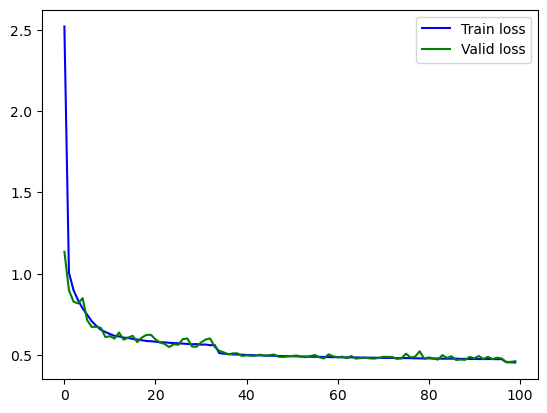

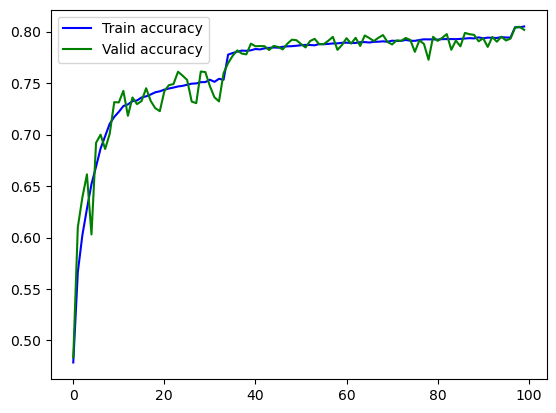

In [392]:
plt.plot(neir_mod.history.history['loss'], color = "b", label = 'Train loss')
plt.plot(neir_mod.history.history['val_loss'], color = "g", label = 'Valid loss')
plt.legend()
plt.show()

plt.plot(neir_mod.history.history['accuracy'], color = "b", label = 'Train accuracy')
plt.plot(neir_mod.history.history['val_accuracy'], color = "g", label = 'Valid accuracy')
plt.legend()
plt.show()

Я пришёл к тому, что результаты хуже, чем у всех остальных, я могу это связать с тем, что у еня изначально сильных корреляций не было, так что все признаке в сумме давали нужный результат, тогда как если убрать часть из них - точность падает. 

Сравнение
-

несмотря на более плохие результаты по сравнению с предшественниками побеждает всё равно нейронная сеть

Работа с масштабированными построенными данными
=

Масштабирование
-

In [394]:
transformer = Normalizer(copy = True ).fit(X_mod_learn)
X_scaled_mod_learn = transformer.transform(X_mod_learn)
X_scaled_mod_control = transformer.transform(X_mod_control)
X_scaled_od_test = transformer.transform(X_mod_test)

Логистическая сеть
-

In [397]:
log_scaled_mod = LogisticRegression( solver = "lbfgs",C = 0.1, max_iter=300, class_weight="balanced")
log_scaled_mod.fit(X_scaled_mod_learn, Y_mod_learn)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [398]:
y_pred_scaled = log_scaled_mod.predict(X_scaled_mod_learn)
print("Сбалансированная точность модели на обучающей выборке:")
print(balanced_accuracy_score(Y_mod_learn, y_pred_scaled), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_mod_learn, y_pred_scaled), "\n")
print("F1 метрики для модели на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_learn, y_pred_scaled, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_learn, y_pred_scaled, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на обучающей выборке:
0.3807969428335815 

Confusion_matrix модели на обучающей выборке:
[[29663 21502 13195   565 12242 23623 59689]
 [30291 44479 22084  5766 22347 34950 68562]
 [   45   268  8624  7590  1454  4823  2310]
 [    2     0   214  1939   174   121    14]
 [  420   356  1581   856  1637  1235  2123]
 [  126   268  3317  2551   433  4452  2214]
 [ 1295  1192   502     0   280  2601  9704]] 

F1 метрики для модели на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.18172793358061776
F1 метрики по отдельным классам: 
Cover_Type_0: 0.2668
Cover_Type_1: 0.3000
Cover_Type_2: 0.2311
Cover_Type_3: 0.1785
Cover_Type_4: 0.0700
Cover_Type_5: 0.1045
Cover_Type_6: 0.1212


Видим в целом стабильно низкий результат, проверю на контрольной выборке

In [400]:
y_pred_scaled_control = log_scaled_mod.predict(X_scaled_mod_control)
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_mod_control, y_pred_scaled_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_mod_control, y_pred_scaled_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_control, y_pred_scaled_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_control, y_pred_scaled_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.3806958679002951 

Confusion_matrix модели на контрольной выборке:
[[1706 1200  751   40  654 1284 3367]
 [1669 2439 1201  301 1205 1927 3833]
 [   2   16  486  409   74  264  116]
 [   0    0   19  106   10    8    1]
 [  32   14  109   43  110   74  121]
 [   9   17  182  148   24  243  105]
 [  74   73   24    0   18  132  564]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.18557002525507696
F1 метрики по отдельным классам: 
Cover_Type_1: 0.2731
Cover_Type_2: 0.2986
Cover_Type_3: 0.2348
Cover_Type_4: 0.1780
Cover_Type_5: 0.0847
Cover_Type_6: 0.1043
Cover_Type_7: 0.1254


Результат стал не лучше , так что перейдём к нейронной сети

Нейронная сеть
-

In [423]:
neir_mod_scaled = models.Sequential()
neir_mod_scaled.add(layers.Dense(11, activation='relu', input_shape = (11,)))
neir_mod_scaled.add(layers.BatchNormalization())
neir_mod_scaled.add(layers.Dense(128, activation='relu'))
neir_mod_scaled.add(layers.BatchNormalization())
neir_mod_scaled.add(layers.Dense(64, activation='relu'))
neir_mod_scaled.add(layers.BatchNormalization())
neir_mod_scaled.add(layers.Dense(7, activation='softmax'))
neir_mod_scaled.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 11)             │            44 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,191 (43.71 KB)

 Trainable params: 10,785 (42.13 KB)

 Non-trainable params: 406 (1.59 KB)

In [424]:
neir_mod_scaled.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_mod_scaled.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir4 = neir_mod_scaled.fit(X_scaled_mod_learn, Y_mod_learn, validation_data=(X_scaled_mod_control, Y_mod_control), callbacks = callbacks_list, epochs=150, batch_size=500)

Epoch 1/150
907/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5353 - loss: 1.2148

908/908 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5852 - loss: 0.9936 - val_accuracy: 0.6054 - val_loss: 0.8898 - learning_rate: 0.0010
Epoch 2/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6320 - loss: 0.8164 - val_accuracy: 0.5222 - val_loss: 1.2489 - learning_rate: 0.0010
Epoch 3/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6555 - loss: 0.7608 - val_accuracy: 0.4281 - val_loss: 2.9282 - learning_rate: 0.0010
Epoch 4/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6703 - loss: 0.7285 - val_accuracy: 0.4558 - val_loss: 3.4562 - learning_rate: 0.0010
Epoch 5/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6815 - loss: 0.7045 - val_accuracy: 0.1088 - val_loss: 10.8008 - learning_rate: 0.0010
Epoch 6/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6880 - loss: 0.6899 - val_accuracy: 0.3768 - val_loss: 2.6154 - learning_rate: 0.0010
Epoch 7/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6962 - loss: 0.6752 - val_

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7320 - loss: 0.6042 - val_accuracy: 0.6828 - val_loss: 0.7100 - learning_rate: 2.5000e-04
Epoch 14/150
904/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7322 - loss: 0.6028

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7334 - loss: 0.6011 - val_accuracy: 0.7345 - val_loss: 0.5991 - learning_rate: 2.5000e-04
Epoch 15/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7343 - loss: 0.5985 - val_accuracy: 0.6437 - val_loss: 0.8777 - learning_rate: 2.5000e-04
Epoch 16/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7359 - loss: 0.5961 - val_accuracy: 0.6287 - val_loss: 0.9701 - learning_rate: 2.5000e-04
Epoch 17/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7371 - loss: 0.5929 - val_accuracy: 0.4213 - val_loss: 3.1230 - learning_rate: 2.5000e-04
Epoch 18/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7374 - loss: 0.5921 - val_accuracy: 0.5936 - val_loss: 1.1288 - learning_rate: 2.5000e-04
Epoch 19/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7382 - loss: 0.5895 - val_accuracy: 0.5496 - val_loss: 1.3242 - learning_rate: 2.5000e-04
Epoch 20/150
905/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7399 - loss: 0.5875 - val_accuracy: 0.7456 - val_loss: 0.5801 - learning_rate: 2.5000e-04
Epoch 21/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7407 - loss: 0.5860 - val_accuracy: 0.6535 - val_loss: 0.8586 - learning_rate: 2.5000e-04
Epoch 22/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7417 - loss: 0.5838 - val_accuracy: 0.3649 - val_loss: 4.7105 - learning_rate: 2.5000e-04
Epoch 23/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7430 - loss: 0.5815 - val_accuracy: 0.4950 - val_loss: 2.6484 - learning_rate: 2.5000e-04
Epoch 24/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7440 - loss: 0.5792 - val_accuracy: 0.5570 - val_loss: 1.4296 - learning_rate: 2.5000e-04
Epoch 25/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7448 - loss: 0.5771 - val_accuracy: 0.6052 - val_loss: 0.9899 - learning_rate: 2.5000e-04
Epoch 26/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy:

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7534 - loss: 0.5594 - val_accuracy: 0.7640 - val_loss: 0.5459 - learning_rate: 6.2500e-05
Epoch 32/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7539 - loss: 0.5586 - val_accuracy: 0.5358 - val_loss: 1.6332 - learning_rate: 6.2500e-05
Epoch 33/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7545 - loss: 0.5587 - val_accuracy: 0.6714 - val_loss: 0.7267 - learning_rate: 6.2500e-05
Epoch 34/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7545 - loss: 0.5580 - val_accuracy: 0.7623 - val_loss: 0.5502 - learning_rate: 6.2500e-05
Epoch 35/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7563 - loss: 0.5556 - val_accuracy: 0.6897 - val_loss: 0.6905 - learning_rate: 6.2500e-05
Epoch 36/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7556 - loss: 0.5563 - val_accuracy: 0.6177 - val_loss: 0.9153 - learning_rate: 6.2500e-05
Epoch 37/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy:

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7589 - loss: 0.5506 - val_accuracy: 0.7697 - val_loss: 0.5316 - learning_rate: 1.5625e-05
Epoch 44/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7589 - loss: 0.5511 - val_accuracy: 0.7481 - val_loss: 0.5696 - learning_rate: 1.5625e-05
Epoch 45/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7585 - loss: 0.5504 - val_accuracy: 0.7692 - val_loss: 0.5405 - learning_rate: 1.5625e-05
Epoch 46/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7586 - loss: 0.5502 - val_accuracy: 0.7381 - val_loss: 0.5976 - learning_rate: 1.5625e-05
Epoch 47/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7599 - loss: 0.5490 - val_accuracy: 0.7367 - val_loss: 0.5980 - learning_rate: 1.5625e-05
Epoch 48/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7600 - loss: 0.5493 - val_accuracy: 0.7688 - val_loss: 0.5315 - learning_rate: 1.5625e-05
Epoch 49/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy:

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7606 - loss: 0.5467 - val_accuracy: 0.7730 - val_loss: 0.5297 - learning_rate: 3.9063e-06
Epoch 60/150
897/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7612 - loss: 0.5453

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7601 - loss: 0.5475 - val_accuracy: 0.7732 - val_loss: 0.5279 - learning_rate: 3.9063e-06
Epoch 61/150
894/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7603 - loss: 0.5477

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7606 - loss: 0.5475 - val_accuracy: 0.7737 - val_loss: 0.5297 - learning_rate: 3.9063e-06
Epoch 62/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7603 - loss: 0.5469 - val_accuracy: 0.7733 - val_loss: 0.5292 - learning_rate: 3.9063e-06
Epoch 63/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7603 - loss: 0.5474 - val_accuracy: 0.7723 - val_loss: 0.5285 - learning_rate: 3.9063e-06
Epoch 64/150
897/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7598 - loss: 0.5476

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7605 - loss: 0.5468 - val_accuracy: 0.7740 - val_loss: 0.5286 - learning_rate: 3.9063e-06
Epoch 65/150
893/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7592 - loss: 0.5486

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7595 - loss: 0.5472 - val_accuracy: 0.7742 - val_loss: 0.5302 - learning_rate: 3.9063e-06
Epoch 66/150
896/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7609 - loss: 0.5452

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7605 - loss: 0.5467 - val_accuracy: 0.7744 - val_loss: 0.5288 - learning_rate: 3.9063e-06
Epoch 67/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7604 - loss: 0.5474 - val_accuracy: 0.7722 - val_loss: 0.5328 - learning_rate: 3.9063e-06
Epoch 68/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7597 - loss: 0.5475 - val_accuracy: 0.7713 - val_loss: 0.5282 - learning_rate: 3.9063e-06
Epoch 69/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7601 - loss: 0.5464 - val_accuracy: 0.7736 - val_loss: 0.5299 - learning_rate: 3.9063e-06
Epoch 70/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7605 - loss: 0.5472 - val_accuracy: 0.7738 - val_loss: 0.5281 - learning_rate: 3.9063e-06
Epoch 71/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7599 - loss: 0.5477 - val_accuracy: 0.7739 - val_loss: 0.5271 - learning_rate: 9.7656e-07
Epoch 72/150
899/908 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7610 - loss: 0.5464 - val_accuracy: 0.7748 - val_loss: 0.5274 - learning_rate: 9.7656e-07
Epoch 73/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7607 - loss: 0.5468 - val_accuracy: 0.7746 - val_loss: 0.5274 - learning_rate: 9.7656e-07
Epoch 74/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7611 - loss: 0.5468 - val_accuracy: 0.7740 - val_loss: 0.5276 - learning_rate: 9.7656e-07
Epoch 75/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7606 - loss: 0.5468 - val_accuracy: 0.7746 - val_loss: 0.5273 - learning_rate: 9.7656e-07
Epoch 76/150
906/908 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7605 - loss: 0.5479

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7608 - loss: 0.5468 - val_accuracy: 0.7752 - val_loss: 0.5278 - learning_rate: 9.7656e-07
Epoch 77/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7605 - loss: 0.5460 - val_accuracy: 0.7741 - val_loss: 0.5271 - learning_rate: 9.7656e-07
Epoch 78/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7602 - loss: 0.5470 - val_accuracy: 0.7748 - val_loss: 0.5270 - learning_rate: 9.7656e-07
Epoch 79/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7607 - loss: 0.5465 - val_accuracy: 0.7742 - val_loss: 0.5273 - learning_rate: 9.7656e-07
Epoch 80/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7602 - loss: 0.5467 - val_accuracy: 0.7740 - val_loss: 0.5272 - learning_rate: 9.7656e-07
Epoch 81/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7600 - loss: 0.5466 - val_accuracy: 0.7743 - val_loss: 0.5275 - learning_rate: 9.7656e-07
Epoch 82/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy:

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7606 - loss: 0.5469 - val_accuracy: 0.7756 - val_loss: 0.5283 - learning_rate: 9.7656e-07
Epoch 85/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7605 - loss: 0.5464 - val_accuracy: 0.7744 - val_loss: 0.5272 - learning_rate: 9.7656e-07
Epoch 86/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7614 - loss: 0.5456 - val_accuracy: 0.7732 - val_loss: 0.5275 - learning_rate: 9.7656e-07
Epoch 87/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7613 - loss: 0.5450 - val_accuracy: 0.7740 - val_loss: 0.5271 - learning_rate: 9.7656e-07
Epoch 88/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7605 - loss: 0.5468 - val_accuracy: 0.7737 - val_loss: 0.5271 - learning_rate: 9.7656e-07
Epoch 89/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7605 - loss: 0.5462 - val_accuracy: 0.7746 - val_loss: 0.5272 - learning_rate: 2.4414e-07
Epoch 90/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy:

908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7608 - loss: 0.5462 - val_accuracy: 0.7759 - val_loss: 0.5273 - learning_rate: 1.5259e-08
Epoch 124/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7602 - loss: 0.5470 - val_accuracy: 0.7749 - val_loss: 0.5271 - learning_rate: 1.5259e-08
Epoch 125/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7605 - loss: 0.5460 - val_accuracy: 0.7741 - val_loss: 0.5268 - learning_rate: 1.5259e-08
Epoch 126/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7607 - loss: 0.5462 - val_accuracy: 0.7746 - val_loss: 0.5271 - learning_rate: 1.5259e-08
Epoch 127/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7605 - loss: 0.5473 - val_accuracy: 0.7754 - val_loss: 0.5270 - learning_rate: 1.5259e-08
Epoch 128/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7604 - loss: 0.5466 - val_accuracy: 0.7746 - val_loss: 0.5270 - learning_rate: 1.5259e-08
Epoch 129/150
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - acc

In [425]:
best_nier_scaled_mod = load_model("Neir_mod_scaled.h5")
y_pred_origin = best_nier_scaled_mod.predict(X_scaled_mod_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)

14178/14178 ━━━━━━━━━━━━━━━━━━━━ 12s 818us/step


In [426]:
print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_mod_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_mod_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.6285803445326688 

Confusion_matrix модели на обучающей выборке:
[[113885  44837     26      0    132      2   1597]
 [ 28450 197096   1465      1    592    610    265]
 [    23   2791  19689    214     67   2329      1]
 [     0      2    858   1371      0    233      0]
 [   379   5045    185      0   2562     31      6]
 [    17   2096   3566    102     45   7535      0]
 [  4667   1387      0      0      0      0   9520]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.6807085273021788
F1 метрики по отдельным классам: 
Cover_Type_0: 0.7398
Cover_Type_1: 0.8183
Cover_Type_2: 0.7736
Cover_Type_3: 0.6604
Cover_Type_4: 0.4415
Cover_Type_5: 0.6253
Cover_Type_6: 0.7062


Тут результаты лучше, однако по сравнениб с предущими неронными моделями он заметно отстаёт . Выполню проверку на контрольной выборке

In [427]:
y_pred_origin_control = best_nier_scaled_mod.predict(X_scaled_mod_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step


In [428]:
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_mod_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_mod_control, y_pred_origin_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_mod_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_mod_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.6147912977504825 

Confusion_matrix модели на контрольной выборке:
[[ 6444  2464     0     0    12     1    81]
 [ 1539 10873    80     0    34    31    18]
 [    2   146  1083     7     6   123     0]
 [    0     0    64    67     0    13     0]
 [   25   316     8     0   153     0     1]
 [    1   106   185    11     4   421     0]
 [  286    83     0     0     0     0   516]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.6689504328530865
F1 метрики по отдельным классам: 
Cover_Type_1: 0.7450
Cover_Type_2: 0.8187
Cover_Type_3: 0.7772
Cover_Type_4: 0.5852
Cover_Type_5: 0.4298
Cover_Type_6: 0.6393
Cover_Type_7: 0.6875


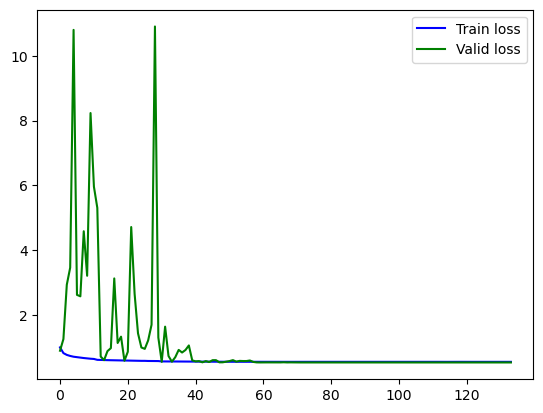

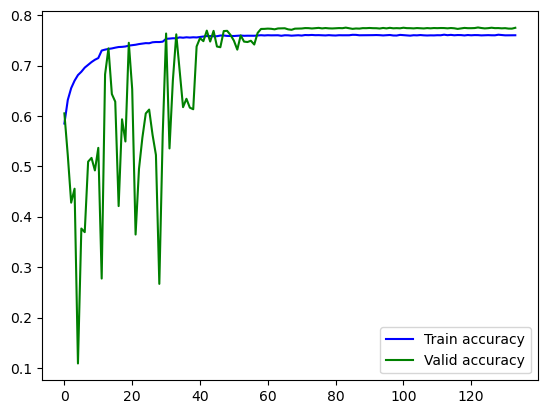

In [431]:
plt.plot(neir_mod_scaled.history.history['loss'], color = "b", label = 'Train loss')
plt.plot(neir_mod_scaled.history.history['val_loss'], color = "g", label = 'Valid loss')
plt.legend()
plt.show()

plt.plot(neir_mod_scaled.history.history['accuracy'], color = "b", label = 'Train accuracy')
plt.plot(neir_mod_scaled.history.history['val_accuracy'], color = "g", label = 'Valid accuracy')
plt.legend()
plt.show()

Предполгаю, что подобные скачки вызваны размером bath

Я думаю, что здесь модели столкнулись с той же проблемой, что и просто при построенных данных, только наложилось ещё и не совсем подходящее масштабирование.

Сравнение
-

Тут тоже побеждает нейронная сеть в сравнение с логистической регрессией

Итоговое сравнение и работа с лучшими
=

Из итогового сравнения будут выброшены логистические регрессии, так как они заметно уступают качеством.

In [432]:
neir_origin_acc = 0.7905913543822484
neir_origin_f1 = 0.8174626847686969

neir_scaled_acc = 0.7874937730407431 
neir_scaled_f1 = 0.8086522849868755

neir_mod_acc = 0.6635225746777847
neir_mod_f1 =0.7010150508084323

neir_mod_scaled_acc = 0.6147912977504825
neir_mod_scaled_f1 =0.6689504328530865 

Тут без всяких сомнений побеждает первая нейронная сеть, на обычны данных . Возьмём её за базу и попробуем улучшить, только вместo adam будем использовать nadam,чттобы проверить ускоренный градиент нестерова

In [454]:
l1_rate = 0.001

neir_origin1 = models.Sequential()
neir_origin1.add(layers.Dense(128,kernel_regularizer=regularizers.l1(l1_rate) , activation='relu'))
neir_origin1.add(layers.BatchNormalization())
neir_origin1.add(layers.Dense(64,kernel_regularizer=regularizers.l1(l1_rate) , activation='relu'))
neir_origin1.add(layers.BatchNormalization())
neir_origin1.add(layers.Dense(32,kernel_regularizer=regularizers.l1(l1_rate) , activation='relu'))
neir_origin1.add(layers.BatchNormalization())
neir_origin1.add(layers.Dense(7, activation='softmax'))
neir_origin1.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = optimizers.Nadam(
    learning_rate = 0.001,
    beta_1 = 0.9,
    beta_2 = 0.999,
    epsilon = 1e-07)

neir_origin1.compile(optimizer = opt, loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_origin1.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir1 = neir_origin1.fit(X_original_learn, Y_original_learn, validation_data=(X_original_control, Y_original_control), callbacks = callbacks_list, epochs=100, batch_size=128)

Epoch 1/100
3541/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6977 - loss: 1.3448

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7262 - loss: 0.9724 - val_accuracy: 0.7454 - val_loss: 0.7069 - learning_rate: 0.0010
Epoch 2/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7469 - loss: 0.6789 - val_accuracy: 0.7281 - val_loss: 0.6825 - learning_rate: 0.0010
Epoch 3/100
3536/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7577 - loss: 0.6431

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7586 - loss: 0.6367 - val_accuracy: 0.7504 - val_loss: 0.6594 - learning_rate: 0.0010
Epoch 4/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7642 - loss: 0.6181 - val_accuracy: 0.7440 - val_loss: 0.6368 - learning_rate: 0.0010
Epoch 5/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7678 - loss: 0.6094 - val_accuracy: 0.7415 - val_loss: 0.6564 - learning_rate: 0.0010
Epoch 6/100
3534/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7705 - loss: 0.6022

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7708 - loss: 0.6026 - val_accuracy: 0.7548 - val_loss: 0.6248 - learning_rate: 0.0010
Epoch 7/100
3530/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7726 - loss: 0.5982

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7727 - loss: 0.5985 - val_accuracy: 0.7740 - val_loss: 0.6008 - learning_rate: 0.0010
Epoch 8/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7751 - loss: 0.5954 - val_accuracy: 0.7121 - val_loss: 0.7129 - learning_rate: 0.0010
Epoch 9/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7759 - loss: 0.5940

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7759 - loss: 0.5938 - val_accuracy: 0.7782 - val_loss: 0.5862 - learning_rate: 0.0010
Epoch 10/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7769 - loss: 0.5924 - val_accuracy: 0.7638 - val_loss: 0.6269 - learning_rate: 0.0010
Epoch 11/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7774 - loss: 0.5914 - val_accuracy: 0.7723 - val_loss: 0.5920 - learning_rate: 0.0010
Epoch 12/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7786 - loss: 0.5910 - val_accuracy: 0.7126 - val_loss: 0.7470 - learning_rate: 0.0010
Epoch 13/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7789 - loss: 0.5892 - val_accuracy: 0.7752 - val_loss: 0.5957 - learning_rate: 0.0010
Epoch 14/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7798 - loss: 0.5874 - val_accuracy: 0.7774 - val_loss: 0.5866 - learning_rate: 0.0010
Epoch 15/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7805 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7804 - loss: 0.5868 - val_accuracy: 0.7807 - val_loss: 0.5793 - learning_rate: 0.0010
Epoch 18/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7800 - loss: 0.5873

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7802 - loss: 0.5870 - val_accuracy: 0.7877 - val_loss: 0.5683 - learning_rate: 0.0010
Epoch 19/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7811 - loss: 0.5854 - val_accuracy: 0.7690 - val_loss: 0.5993 - learning_rate: 0.0010
Epoch 20/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7815 - loss: 0.5859 - val_accuracy: 0.7702 - val_loss: 0.5938 - learning_rate: 0.0010
Epoch 21/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7806 - loss: 0.5853 - val_accuracy: 0.7865 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 22/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7810 - loss: 0.5849 - val_accuracy: 0.7777 - val_loss: 0.5961 - learning_rate: 0.0010
Epoch 23/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7811 - loss: 0.5856

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7811 - loss: 0.5851 - val_accuracy: 0.7879 - val_loss: 0.5685 - learning_rate: 0.0010
Epoch 24/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7814 - loss: 0.5842 - val_accuracy: 0.7874 - val_loss: 0.5643 - learning_rate: 0.0010
Epoch 25/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7824 - loss: 0.5850 - val_accuracy: 0.7853 - val_loss: 0.5775 - learning_rate: 0.0010
Epoch 26/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7823 - loss: 0.5844 - val_accuracy: 0.7760 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 27/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7823 - loss: 0.5841 - val_accuracy: 0.7818 - val_loss: 0.5883 - learning_rate: 0.0010
Epoch 28/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7827 - loss: 0.5828 - val_accuracy: 0.7786 - val_loss: 0.5868 - learning_rate: 0.0010
Epoch 29/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7823 -

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7822 - loss: 0.5819 - val_accuracy: 0.7917 - val_loss: 0.5596 - learning_rate: 0.0010
Epoch 33/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7821 - loss: 0.5810 - val_accuracy: 0.7615 - val_loss: 0.6075 - learning_rate: 0.0010
Epoch 34/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7831 - loss: 0.5798 - val_accuracy: 0.7871 - val_loss: 0.5717 - learning_rate: 0.0010
Epoch 35/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7820 - loss: 0.5807 - val_accuracy: 0.7877 - val_loss: 0.5631 - learning_rate: 0.0010
Epoch 36/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7837 - loss: 0.5787 - val_accuracy: 0.7765 - val_loss: 0.5896 - learning_rate: 0.0010
Epoch 37/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7829 - loss: 0.5806 - val_accuracy: 0.7866 - val_loss: 0.5686 - learning_rate: 0.0010
Epoch 38/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7844 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7994 - loss: 0.5390 - val_accuracy: 0.8146 - val_loss: 0.5085 - learning_rate: 2.5000e-04
Epoch 44/100
3534/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7996 - loss: 0.5326

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8007 - loss: 0.5303 - val_accuracy: 0.8191 - val_loss: 0.4928 - learning_rate: 2.5000e-04
Epoch 45/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8019 - loss: 0.5264 - val_accuracy: 0.8164 - val_loss: 0.4947 - learning_rate: 2.5000e-04
Epoch 46/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8017 - loss: 0.5238 - val_accuracy: 0.8138 - val_loss: 0.4950 - learning_rate: 2.5000e-04
Epoch 47/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8012 - loss: 0.5220 - val_accuracy: 0.8127 - val_loss: 0.4949 - learning_rate: 2.5000e-04
Epoch 48/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8018 - loss: 0.5188 - val_accuracy: 0.8116 - val_loss: 0.4933 - learning_rate: 2.5000e-04
Epoch 49/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8022 - loss: 0.5187 - val_accuracy: 0.8027 - val_loss: 0.5067 - learning_rate: 2.5000e-04
Epoch 50/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/s

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8134 - loss: 0.4848 - val_accuracy: 0.8343 - val_loss: 0.4444 - learning_rate: 6.2500e-05
Epoch 84/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8144 - loss: 0.4824 - val_accuracy: 0.8331 - val_loss: 0.4443 - learning_rate: 6.2500e-05
Epoch 85/100
3526/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.4805

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8145 - loss: 0.4819 - val_accuracy: 0.8358 - val_loss: 0.4402 - learning_rate: 6.2500e-05
Epoch 86/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8147 - loss: 0.4805 - val_accuracy: 0.8322 - val_loss: 0.4424 - learning_rate: 6.2500e-05
Epoch 87/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8151 - loss: 0.4804 - val_accuracy: 0.8328 - val_loss: 0.4418 - learning_rate: 6.2500e-05
Epoch 88/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8156 - loss: 0.4791 - val_accuracy: 0.8355 - val_loss: 0.4400 - learning_rate: 6.2500e-05
Epoch 89/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8145 - loss: 0.4795

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8148 - loss: 0.4788 - val_accuracy: 0.8362 - val_loss: 0.4362 - learning_rate: 6.2500e-05
Epoch 90/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8147 - loss: 0.4792 - val_accuracy: 0.8331 - val_loss: 0.4412 - learning_rate: 6.2500e-05
Epoch 91/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8153 - loss: 0.4777 - val_accuracy: 0.8350 - val_loss: 0.4377 - learning_rate: 6.2500e-05
Epoch 92/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8145 - loss: 0.4776 - val_accuracy: 0.8352 - val_loss: 0.4356 - learning_rate: 6.2500e-05
Epoch 93/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8152 - loss: 0.4764 - val_accuracy: 0.8352 - val_loss: 0.4368 - learning_rate: 6.2500e-05
Epoch 94/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8152 - loss: 0.4759 - val_accuracy: 0.8342 - val_loss: 0.4395 - learning_rate: 6.2500e-05
Epoch 95/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

In [456]:
best_nier_origin1 = load_model("Neir_origin1.h5")
y_pred_origin = best_nier_origin1.predict(X_original_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)

14178/14178 ━━━━━━━━━━━━━━━━━━━━ 13s 898us/step


In [457]:
print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.7234846087547184 

Confusion_matrix модели на обучающей выборке:
[[129163  29379      1      0    104     27   1698]
 [ 22074 203486   1082      6    801    900    242]
 [    20   1816  20796    246     15   2123      0]
 [     0      0    622   1590      0    243      0]
 [   219   4398    137      1   3463    107      0]
 [    14   1273   3087     94      1   8924      0]
 [  2792    196      0      0      0      0  12539]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.7581367395210268
F1 метрики по отдельным классам: 
Cover_Type_0: 0.8210
Cover_Type_1: 0.8675
Cover_Type_2: 0.8197
Cover_Type_3: 0.7240
Cover_Type_4: 0.5450
Cover_Type_5: 0.6940
Cover_Type_6: 0.8358


In [458]:
y_pred_origin_control = best_nier_origin1.predict(X_original_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step


In [459]:
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_origin_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.7131304384364058 

Confusion_matrix модели на контрольной выборке:
[[ 7224  1666     0     0     5     3    97]
 [ 1246 11171    66     0    34    48     6]
 [    2    90  1240    10     0   115     0]
 [    0     0    34    72     0    12     0]
 [   12   238     4     0   161     5     0]
 [    0    71   175     6     0   483     0]
 [  166    17     0     0     0     0   725]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.7514939951363894
F1 метрики по отдельным классам: 
Cover_Type_1: 0.8188
Cover_Type_2: 0.8652
Cover_Type_3: 0.8333
Cover_Type_4: 0.6990
Cover_Type_5: 0.5194
Cover_Type_6: 0.6895
Cover_Type_7: 0.8353


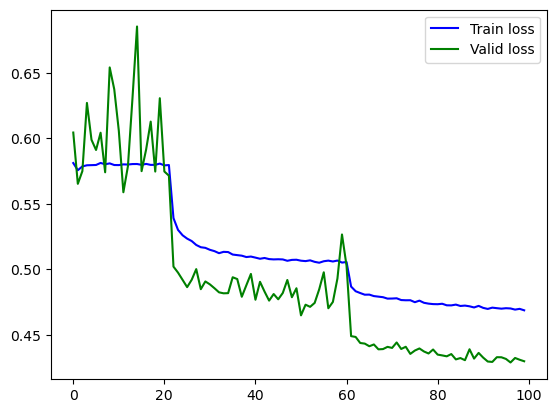

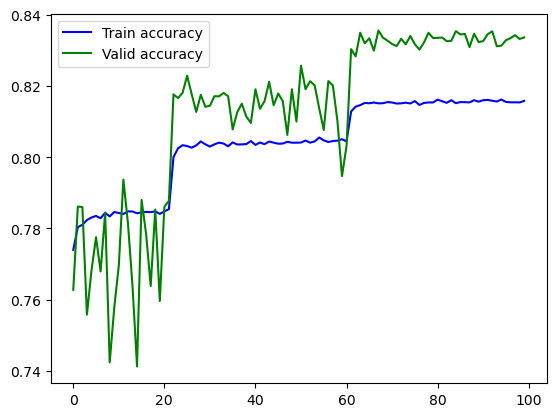

In [465]:
plt.plot(neir_origin1.history.history['loss'], color = "b", label = 'Train loss')
plt.plot(neir_origin1.history.history['val_loss'], color = "g", label = 'Valid loss')
plt.legend()
plt.show()

plt.plot(neir_origin1.history.history['accuracy'], color = "b", label = 'Train accuracy')
plt.plot(neir_origin1.history.history['val_accuracy'], color = "g", label = 'Valid accuracy')
plt.legend()
plt.show()

Получилос хуже чем было, попробую вернуть обычным adam

In [460]:

neir_origin1.compile(optimizer = "adam", loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_origin1.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir1 = neir_origin1.fit(X_original_learn, Y_original_learn, validation_data=(X_original_control, Y_original_control), callbacks = callbacks_list, epochs=100, batch_size=128)

Epoch 1/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7691 - loss: 0.5914

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7740 - loss: 0.5812 - val_accuracy: 0.7628 - val_loss: 0.6045 - learning_rate: 0.0010
Epoch 2/100
3525/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7788 - loss: 0.5766

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7804 - loss: 0.5757 - val_accuracy: 0.7861 - val_loss: 0.5653 - learning_rate: 0.0010
Epoch 3/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7810 - loss: 0.5786 - val_accuracy: 0.7860 - val_loss: 0.5750 - learning_rate: 0.0010
Epoch 4/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7824 - loss: 0.5795 - val_accuracy: 0.7558 - val_loss: 0.6271 - learning_rate: 0.0010
Epoch 5/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7831 - loss: 0.5796 - val_accuracy: 0.7682 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 6/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7835 - loss: 0.5797 - val_accuracy: 0.7776 - val_loss: 0.5912 - learning_rate: 0.0010
Epoch 7/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7829 - loss: 0.5813 - val_accuracy: 0.7679 - val_loss: 0.6043 - learning_rate: 0.0010
Epoch 8/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7844 - loss: 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7841 - loss: 0.5802 - val_accuracy: 0.7937 - val_loss: 0.5589 - learning_rate: 0.0010
Epoch 13/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7848 - loss: 0.5801 - val_accuracy: 0.7815 - val_loss: 0.5787 - learning_rate: 0.0010
Epoch 14/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7848 - loss: 0.5804 - val_accuracy: 0.7640 - val_loss: 0.6306 - learning_rate: 0.0010
Epoch 15/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7843 - loss: 0.5805 - val_accuracy: 0.7413 - val_loss: 0.6854 - learning_rate: 0.0010
Epoch 16/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7845 - loss: 0.5798 - val_accuracy: 0.7880 - val_loss: 0.5750 - learning_rate: 0.0010
Epoch 17/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7846 - loss: 0.5805 - val_accuracy: 0.7784 - val_loss: 0.5916 - learning_rate: 0.0010
Epoch 18/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7846 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8000 - loss: 0.5392 - val_accuracy: 0.8176 - val_loss: 0.5022 - learning_rate: 2.5000e-04
Epoch 24/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8025 - loss: 0.5302 - val_accuracy: 0.8166 - val_loss: 0.4976 - learning_rate: 2.5000e-04
Epoch 25/100
3529/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8028 - loss: 0.5285

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8034 - loss: 0.5261 - val_accuracy: 0.8181 - val_loss: 0.4921 - learning_rate: 2.5000e-04
Epoch 26/100
3539/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8037 - loss: 0.5242

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8031 - loss: 0.5235 - val_accuracy: 0.8229 - val_loss: 0.4865 - learning_rate: 2.5000e-04
Epoch 27/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8027 - loss: 0.5217 - val_accuracy: 0.8177 - val_loss: 0.4921 - learning_rate: 2.5000e-04
Epoch 28/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8033 - loss: 0.5187 - val_accuracy: 0.8127 - val_loss: 0.5002 - learning_rate: 2.5000e-04
Epoch 29/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8044 - loss: 0.5170 - val_accuracy: 0.8175 - val_loss: 0.4849 - learning_rate: 2.5000e-04
Epoch 30/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8036 - loss: 0.5165 - val_accuracy: 0.8142 - val_loss: 0.4908 - learning_rate: 2.5000e-04
Epoch 31/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8030 - loss: 0.5150 - val_accuracy: 0.8145 - val_loss: 0.4886 - learning_rate: 2.5000e-04
Epoch 32/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8041 - loss: 0.5067 - val_accuracy: 0.8257 - val_loss: 0.4650 - learning_rate: 2.5000e-04
Epoch 52/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8047 - loss: 0.5064 - val_accuracy: 0.8191 - val_loss: 0.4731 - learning_rate: 2.5000e-04
Epoch 53/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8041 - loss: 0.5069 - val_accuracy: 0.8213 - val_loss: 0.4715 - learning_rate: 2.5000e-04
Epoch 54/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8044 - loss: 0.5058 - val_accuracy: 0.8202 - val_loss: 0.4745 - learning_rate: 2.5000e-04
Epoch 55/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8055 - loss: 0.5051 - val_accuracy: 0.8137 - val_loss: 0.4849 - learning_rate: 2.5000e-04
Epoch 56/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8047 - loss: 0.5063 - val_accuracy: 0.8076 - val_loss: 0.4978 - learning_rate: 2.5000e-04
Epoch 57/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/s

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8128 - loss: 0.4869 - val_accuracy: 0.8303 - val_loss: 0.4491 - learning_rate: 6.2500e-05
Epoch 63/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8142 - loss: 0.4834 - val_accuracy: 0.8283 - val_loss: 0.4485 - learning_rate: 6.2500e-05
Epoch 64/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8148 - loss: 0.4810

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8146 - loss: 0.4820 - val_accuracy: 0.8349 - val_loss: 0.4439 - learning_rate: 6.2500e-05
Epoch 65/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8152 - loss: 0.4807 - val_accuracy: 0.8320 - val_loss: 0.4434 - learning_rate: 6.2500e-05
Epoch 66/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8151 - loss: 0.4808 - val_accuracy: 0.8334 - val_loss: 0.4414 - learning_rate: 6.2500e-05
Epoch 67/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8154 - loss: 0.4797 - val_accuracy: 0.8299 - val_loss: 0.4428 - learning_rate: 6.2500e-05
Epoch 68/100
3528/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8154 - loss: 0.4782

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8151 - loss: 0.4793 - val_accuracy: 0.8356 - val_loss: 0.4390 - learning_rate: 6.2500e-05
Epoch 69/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8152 - loss: 0.4788 - val_accuracy: 0.8336 - val_loss: 0.4392 - learning_rate: 6.2500e-05
Epoch 70/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8155 - loss: 0.4777 - val_accuracy: 0.8327 - val_loss: 0.4409 - learning_rate: 6.2500e-05
Epoch 71/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8154 - loss: 0.4778 - val_accuracy: 0.8318 - val_loss: 0.4401 - learning_rate: 6.2500e-05
Epoch 72/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8151 - loss: 0.4780 - val_accuracy: 0.8312 - val_loss: 0.4443 - learning_rate: 6.2500e-05
Epoch 73/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8151 - loss: 0.4766 - val_accuracy: 0.8332 - val_loss: 0.4393 - learning_rate: 6.2500e-05
Epoch 74/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

In [461]:
best_nier_origin2 = load_model("Neir_origin1.h5")
y_pred_origin = best_nier_origin2.predict(X_original_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)

14178/14178 ━━━━━━━━━━━━━━━━━━━━ 13s 898us/step


In [462]:

print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.7341676969510376 

Confusion_matrix модели на обучающей выборке:
[[128492  30550     16      0    169     16   1129]
 [ 21047 204314   1258      5   1011    771    185]
 [    11   1599  21084    307     52   1963      0]
 [     0      0    553   1722      0    180      0]
 [   295   3913    165      0   3904     48      0]
 [    23   1266   3202    105     19   8778      0]
 [  3236    248      0      0      1      0  12042]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.7673129516398957
F1 метрики по отдельным классам: 
Cover_Type_0: 0.8198
Cover_Type_1: 0.8685
Cover_Type_2: 0.8221
Cover_Type_3: 0.7497
Cover_Type_4: 0.5792
Cover_Type_5: 0.6981
Cover_Type_6: 0.8338


In [463]:
y_pred_origin_control = best_nier_origin2.predict(X_original_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step


In [464]:
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_origin_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.7227053066938476 

Confusion_matrix модели на контрольной выборке:
[[ 7175  1737     1     0    11     3    68]
 [ 1179 11215    63     0    57    47    10]
 [    1    80  1241    15     6   114     0]
 [    0     0    27    80     0    11     0]
 [   16   216     7     0   179     2     0]
 [    2    71   170     8     3   481     0]
 [  199    20     0     0     0     0   689]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.7551755476246464
F1 метрики по отдельным классам: 
Cover_Type_1: 0.8169
Cover_Type_2: 0.8657
Cover_Type_3: 0.8368
Cover_Type_4: 0.7240
Cover_Type_5: 0.5296
Cover_Type_6: 0.6906
Cover_Type_7: 0.8227


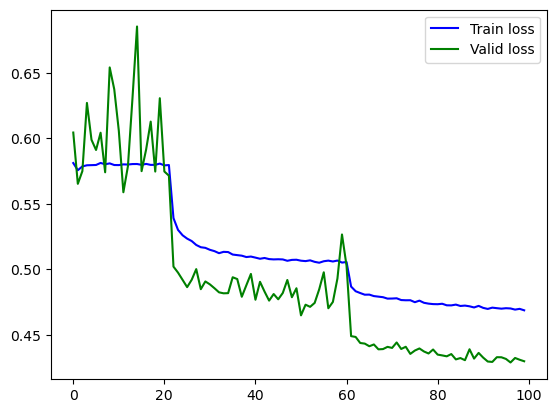

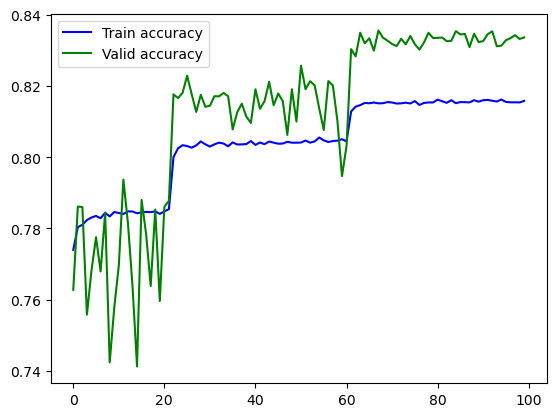

In [466]:
plt.plot(neir_origin1.history.history['loss'], color = "b", label = 'Train loss')
plt.plot(neir_origin1.history.history['val_loss'], color = "g", label = 'Valid loss')
plt.legend()
plt.show()

plt.plot(neir_origin1.history.history['accuracy'], color = "b", label = 'Train accuracy')
plt.plot(neir_origin1.history.history['val_accuracy'], color = "g", label = 'Valid accuracy')
plt.legend()
plt.show()

Мы видим картинку, что скачок в обучении происхоит только в момент изменения скорость обучения( я предполгаю что это именно оно )

Получилось снова не очень, но лучше. Попробую l2 регуляризацию

In [467]:
l2_rate = 0.0001

neir_origin1 = models.Sequential()
neir_origin1.add(layers.Dense(128,kernel_regularizer=regularizers.l2(l2_rate) , activation='relu'))
neir_origin1.add(layers.BatchNormalization())
neir_origin1.add(layers.Dense(64,kernel_regularizer=regularizers.l2(l2_rate) , activation='relu'))
neir_origin1.add(layers.BatchNormalization())
neir_origin1.add(layers.Dense(32,kernel_regularizer=regularizers.l2(l2_rate) , activation='relu'))
neir_origin1.add(layers.BatchNormalization())
neir_origin1.add(layers.Dense(7, activation='softmax'))
neir_origin1.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_91 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [468]:
neir_origin1.compile(optimizer = "adam", loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_origin1.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir1 = neir_origin1.fit(X_original_learn, Y_original_learn, validation_data=(X_original_control, Y_original_control), callbacks = callbacks_list, epochs=100, batch_size=128)

Epoch 1/100
3542/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7043 - loss: 0.7838

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.7374 - loss: 0.6453 - val_accuracy: 0.7504 - val_loss: 0.5853 - learning_rate: 0.0010
Epoch 2/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7799 - loss: 0.5277 - val_accuracy: 0.6964 - val_loss: 0.7255 - learning_rate: 0.0010
Epoch 3/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7945 - loss: 0.4985 - val_accuracy: 0.7101 - val_loss: 0.7342 - learning_rate: 0.0010
Epoch 4/100
3525/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8021 - loss: 0.4828

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8034 - loss: 0.4807 - val_accuracy: 0.7542 - val_loss: 0.6140 - learning_rate: 0.0010
Epoch 5/100
3536/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8098 - loss: 0.4697

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8097 - loss: 0.4683 - val_accuracy: 0.7892 - val_loss: 0.5009 - learning_rate: 0.0010
Epoch 6/100
3537/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8117 - loss: 0.4618

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8142 - loss: 0.4581 - val_accuracy: 0.8223 - val_loss: 0.4380 - learning_rate: 0.0010
Epoch 7/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8186 - loss: 0.4513 - val_accuracy: 0.8083 - val_loss: 0.4699 - learning_rate: 0.0010
Epoch 8/100
3530/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8198 - loss: 0.4474

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8216 - loss: 0.4455 - val_accuracy: 0.8332 - val_loss: 0.4206 - learning_rate: 0.0010
Epoch 9/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8245 - loss: 0.4405 - val_accuracy: 0.7880 - val_loss: 0.5193 - learning_rate: 0.0010
Epoch 10/100
3525/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8260 - loss: 0.4369

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8272 - loss: 0.4355 - val_accuracy: 0.8340 - val_loss: 0.4163 - learning_rate: 0.0010
Epoch 11/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8292 - loss: 0.4316 - val_accuracy: 0.8126 - val_loss: 0.4595 - learning_rate: 0.0010
Epoch 12/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8302 - loss: 0.4284 - val_accuracy: 0.8221 - val_loss: 0.4403 - learning_rate: 0.0010
Epoch 13/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8329 - loss: 0.4240 - val_accuracy: 0.7852 - val_loss: 0.5591 - learning_rate: 0.0010
Epoch 14/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8333 - loss: 0.4234 - val_accuracy: 0.6050 - val_loss: 1.4667 - learning_rate: 0.0010
Epoch 15/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8344 - loss: 0.4213 - val_accuracy: 0.7654 - val_loss: 0.5890 - learning_rate: 0.0010
Epoch 16/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8355 - 

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8547 - loss: 0.3788 - val_accuracy: 0.8710 - val_loss: 0.3463 - learning_rate: 2.5000e-04
Epoch 22/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8561 - loss: 0.3743 - val_accuracy: 0.8273 - val_loss: 0.4475 - learning_rate: 2.5000e-04
Epoch 23/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8570 - loss: 0.3715 - val_accuracy: 0.8625 - val_loss: 0.3614 - learning_rate: 2.5000e-04
Epoch 24/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8573 - loss: 0.3703 - val_accuracy: 0.8036 - val_loss: 0.4869 - learning_rate: 2.5000e-04
Epoch 25/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8579 - loss: 0.3685 - val_accuracy: 0.8682 - val_loss: 0.3452 - learning_rate: 2.5000e-04
Epoch 26/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8583 - loss: 0.3670 - val_accuracy: 0.8701 - val_loss: 0.3417 - learning_rate: 2.5000e-04
Epoch 27/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8593 - loss: 0.3644 - val_accuracy: 0.8789 - val_loss: 0.3271 - learning_rate: 2.5000e-04
Epoch 29/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8593 - loss: 0.3632 - val_accuracy: 0.8752 - val_loss: 0.3335 - learning_rate: 2.5000e-04
Epoch 30/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8596 - loss: 0.3627 - val_accuracy: 0.8714 - val_loss: 0.3339 - learning_rate: 2.5000e-04
Epoch 31/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8596 - loss: 0.3625 - val_accuracy: 0.8725 - val_loss: 0.3345 - learning_rate: 2.5000e-04
Epoch 32/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8608 - loss: 0.3600 - val_accuracy: 0.8680 - val_loss: 0.3409 - learning_rate: 2.5000e-04
Epoch 33/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8605 - loss: 0.3604 - val_accuracy: 0.8364 - val_loss: 0.4281 - learning_rate: 2.5000e-04
Epoch 34/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8621 - loss: 0.3566 - val_accuracy: 0.8801 - val_loss: 0.3196 - learning_rate: 2.5000e-04
Epoch 38/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8617 - loss: 0.3565 - val_accuracy: 0.8730 - val_loss: 0.3312 - learning_rate: 2.5000e-04
Epoch 39/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8618 - loss: 0.3555 - val_accuracy: 0.8297 - val_loss: 0.4254 - learning_rate: 2.5000e-04
Epoch 40/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8622 - loss: 0.3551 - val_accuracy: 0.8542 - val_loss: 0.3743 - learning_rate: 2.5000e-04
Epoch 41/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8624 - loss: 0.3550 - val_accuracy: 0.8784 - val_loss: 0.3226 - learning_rate: 2.5000e-04
Epoch 42/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8633 - loss: 0.3531 - val_accuracy: 0.8356 - val_loss: 0.4083 - learning_rate: 2.5000e-04
Epoch 43/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8633 - loss: 0.3515 - val_accuracy: 0.8823 - val_loss: 0.3120 - learning_rate: 2.5000e-04
Epoch 47/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8632 - loss: 0.3511 - val_accuracy: 0.8726 - val_loss: 0.3290 - learning_rate: 2.5000e-04
Epoch 48/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8637 - loss: 0.3501 - val_accuracy: 0.8228 - val_loss: 0.4476 - learning_rate: 2.5000e-04
Epoch 49/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8629 - loss: 0.3508 - val_accuracy: 0.8756 - val_loss: 0.3287 - learning_rate: 2.5000e-04
Epoch 50/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8636 - loss: 0.3503 - val_accuracy: 0.8782 - val_loss: 0.3194 - learning_rate: 2.5000e-04
Epoch 51/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8634 - loss: 0.3509 - val_accuracy: 0.8402 - val_loss: 0.4022 - learning_rate: 2.5000e-04
Epoch 52/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8703 - loss: 0.3348 - val_accuracy: 0.8899 - val_loss: 0.2930 - learning_rate: 6.2500e-05
Epoch 58/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8713 - loss: 0.3327 - val_accuracy: 0.8878 - val_loss: 0.2997 - learning_rate: 6.2500e-05
Epoch 59/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8705 - loss: 0.3335 - val_accuracy: 0.8789 - val_loss: 0.3128 - learning_rate: 6.2500e-05
Epoch 60/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8710 - loss: 0.3325 - val_accuracy: 0.8834 - val_loss: 0.3096 - learning_rate: 6.2500e-05
Epoch 61/100
3543/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8709 - loss: 0.3313

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8711 - loss: 0.3320 - val_accuracy: 0.8942 - val_loss: 0.2869 - learning_rate: 6.2500e-05
Epoch 62/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8715 - loss: 0.3328 - val_accuracy: 0.8793 - val_loss: 0.3157 - learning_rate: 6.2500e-05
Epoch 63/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8719 - loss: 0.3309 - val_accuracy: 0.8926 - val_loss: 0.2899 - learning_rate: 6.2500e-05
Epoch 64/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8717 - loss: 0.3312 - val_accuracy: 0.8797 - val_loss: 0.3154 - learning_rate: 6.2500e-05
Epoch 65/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8726 - loss: 0.3304 - val_accuracy: 0.8880 - val_loss: 0.2989 - learning_rate: 6.2500e-05
Epoch 66/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8719 - loss: 0.3313 - val_accuracy: 0.8603 - val_loss: 0.3565 - learning_rate: 6.2500e-05
Epoch 67/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8732 - loss: 0.3266 - val_accuracy: 0.8953 - val_loss: 0.2807 - learning_rate: 1.5625e-05
Epoch 73/100
3526/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8743 - loss: 0.3257

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8735 - loss: 0.3267 - val_accuracy: 0.8958 - val_loss: 0.2797 - learning_rate: 1.5625e-05
Epoch 74/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8746 - loss: 0.3251 - val_accuracy: 0.8906 - val_loss: 0.2889 - learning_rate: 1.5625e-05
Epoch 75/100
3542/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8742 - loss: 0.3257

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8743 - loss: 0.3261 - val_accuracy: 0.8962 - val_loss: 0.2792 - learning_rate: 1.5625e-05
Epoch 76/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8736 - loss: 0.3265 - val_accuracy: 0.8953 - val_loss: 0.2798 - learning_rate: 1.5625e-05
Epoch 77/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8735 - loss: 0.3256 - val_accuracy: 0.8953 - val_loss: 0.2797 - learning_rate: 1.5625e-05
Epoch 78/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8741 - loss: 0.3263 - val_accuracy: 0.8961 - val_loss: 0.2788 - learning_rate: 1.5625e-05
Epoch 79/100
3530/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8744 - loss: 0.3242

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8742 - loss: 0.3252 - val_accuracy: 0.8964 - val_loss: 0.2798 - learning_rate: 1.5625e-05
Epoch 80/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8731 - loss: 0.3263 - val_accuracy: 0.8872 - val_loss: 0.2944 - learning_rate: 1.5625e-05
Epoch 81/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8741 - loss: 0.3254 - val_accuracy: 0.8938 - val_loss: 0.2839 - learning_rate: 1.5625e-05
Epoch 82/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8744 - loss: 0.3252 - val_accuracy: 0.8960 - val_loss: 0.2799 - learning_rate: 1.5625e-05
Epoch 83/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8741 - loss: 0.3247 - val_accuracy: 0.8959 - val_loss: 0.2801 - learning_rate: 1.5625e-05
Epoch 84/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8742 - loss: 0.3245 - val_accuracy: 0.8955 - val_loss: 0.2791 - learning_rate: 1.5625e-05
Epoch 85/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8738 - loss: 0.3262 - val_accuracy: 0.8965 - val_loss: 0.2785 - learning_rate: 1.5625e-05
Epoch 87/100
3529/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8731 - loss: 0.3260

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8738 - loss: 0.3257 - val_accuracy: 0.8971 - val_loss: 0.2779 - learning_rate: 1.5625e-05
Epoch 88/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8744 - loss: 0.3248 - val_accuracy: 0.8965 - val_loss: 0.2782 - learning_rate: 1.5625e-05
Epoch 89/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8743 - loss: 0.3248 - val_accuracy: 0.8957 - val_loss: 0.2793 - learning_rate: 1.5625e-05
Epoch 90/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8741 - loss: 0.3247 - val_accuracy: 0.8957 - val_loss: 0.2776 - learning_rate: 1.5625e-05
Epoch 91/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8737 - loss: 0.3255 - val_accuracy: 0.8967 - val_loss: 0.2783 - learning_rate: 1.5625e-05
Epoch 92/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8744 - loss: 0.3250 - val_accuracy: 0.8948 - val_loss: 0.2818 - learning_rate: 1.5625e-05
Epoch 93/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/st

In [469]:
best_nier_origin3 = load_model("Neir_origin1.h5")
y_pred_origin = best_nier_origin3.predict(X_original_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)

14178/14178 ━━━━━━━━━━━━━━━━━━━━ 12s 821us/step


In [470]:

print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.8340952256952356 

Confusion_matrix модели на обучающей выборке:
[[141433  17790      9      0    183     47    910]
 [ 12378 213985    563      8   1038    502    117]
 [    10    623  22063    312     75   1933      0]
 [     0      4    387   1913      0    151      0]
 [   153   2315    203      0   5587     67      0]
 [    50    610   2074    109     30  10520      0]
 [  1358    148      0      0      2      0  14019]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.8476449351710106
F1 метрики по отдельным классам: 
Cover_Type_0: 0.8958
Cover_Type_1: 0.9222
Cover_Type_2: 0.8770
Cover_Type_3: 0.7976
Cover_Type_4: 0.7332
Cover_Type_5: 0.7906
Cover_Type_6: 0.9171


In [471]:
y_pred_origin_control = best_nier_origin3.predict(X_original_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 821us/step


In [472]:
print("Сбалансированная точность модели на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_origin_control), "\n")
print("F1 метрики для модели на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на контрольной выборке:
0.821606207029646 

Confusion_matrix модели на контрольной выборке:
[[ 7875  1050     0     0    14     3    53]
 [  752 11692    30     0    66    28     3]
 [    1    25  1314    11     5   101     0]
 [    0     0    21    88     0     9     0]
 [    6   136    10     0   266     2     0]
 [    2    34   115     7     1   576     0]
 [   95    13     0     0     0     0   800]] 

F1 метрики для модели на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.8386721056667747
F1 метрики по отдельным классам: 
Cover_Type_1: 0.8885
Cover_Type_2: 0.9163
Cover_Type_3: 0.8918
Cover_Type_4: 0.7857
Cover_Type_5: 0.6891
Cover_Type_6: 0.7923
Cover_Type_7: 0.9070


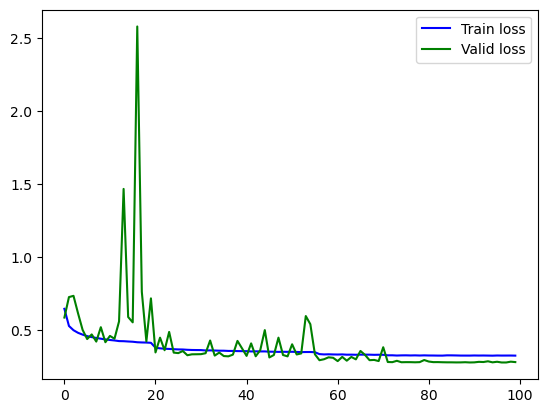

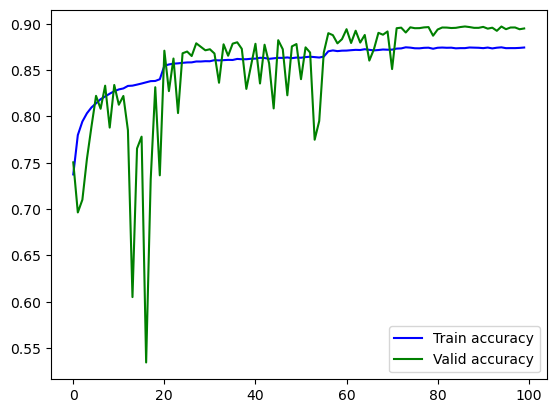

In [473]:
plt.plot(neir_origin1.history.history['loss'], color = "b", label = 'Train loss')
plt.plot(neir_origin1.history.history['val_loss'], color = "g", label = 'Valid loss')
plt.legend()
plt.show()

plt.plot(neir_origin1.history.history['accuracy'], color = "b", label = 'Train accuracy')
plt.plot(neir_origin1.history.history['val_accuracy'], color = "g", label = 'Valid accuracy')
plt.legend()
plt.show()

Мы можем видеть улучшение результата на контрольной выборке !!! проверим на итоговой и если всё хорошо- это и есть наша лучшая модель

In [474]:
y_pred_origin_test = best_nier_origin3.predict(X_original_test)
y_pred_origin_test = np.argmax(y_pred_origin_test, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step


In [475]:
print("Сбалансированная точность модели на тестовой выборке:")
print(balanced_accuracy_score(Y_original_test, y_pred_origin_test), "\n")
print("Confusion_matrix модели на контрольной выборке:")
print(confusion_matrix(Y_original_test, y_pred_origin_test), "\n")
print("F1 метрики для модели на тестовой выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_test, y_pred_origin_test, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_test, y_pred_origin_test, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели на тестовой выборке:
0.8205877733651149 

Confusion_matrix модели на контрольной выборке:
[[ 7852  1092     2     0     6     1    52]
 [  725 11772    37     1    58    24     7]
 [    0    36  1244    13     3   113     0]
 [    0     0    26   102     0     9     0]
 [   14   136     6     0   300     5     0]
 [    2    41   117     6     0   556     0]
 [   85     7     0     0     0     0   755]] 

F1 метрики для модели на тестовой выборке:
F1 по всей выборке: 
Macro f1:  0.8398074572383047
F1 метрики по отдельным классам: 
Cover_Type_1: 0.8881
Cover_Type_2: 0.9158
Cover_Type_3: 0.8757
Cover_Type_4: 0.7876
Cover_Type_5: 0.7246
Cover_Type_6: 0.7776
Cover_Type_7: 0.9091


Можно вижеть весьма хорошие результаты !! оставлю эту модель как лучшую.

Выводы
=

В данной работае я изучил работу с логистической моделью и нейронной сетью. Было изучен полный цикл разработки, а также применено много различных технологий.
В результате оказалось, что лучше всего показала себя нейронная сеть на исходных значениях с l2 регуляризацией и Batch нормализацией. 
лучшие метрики , которых удалось добиться:
+ Сбалансированная точность модели на тестовой выборке: 0.8205877733651149 
+ Macro f1:  0.8398074572383047
+ F1 метрики по отдельным классам: 
    - Cover_Type_1: 0.8881
    - Cover_Type_2: 0.9158
    - Cover_Type_3: 0.8757
    - Cover_Type_4: 0.7876
    - Cover_Type_5: 0.7246
    - Cover_Type_6: 0.7776
    - Cover_Type_7: 0.9091
